# Resistance mutations in aquatic plastisphere microbiomes

All script files are located in `sbatch_files/`. 

Steps before this notebook:
1. Download the fastq data (specified in *download.txt*) using `download.sh` 
2. Run Pipeline 1, see TODO_URL_TO_IT for more details. TODO: Ok to link to it or just describe it?
3. Download the card database using `download_card.sh`
4. Build the database for MuMaMe using `mumame_build.sh`
5. Run MuMaMe using `split_mumame.sh`, it will be grouped according to *beginning_filenames.txt*, in order to speed up the operation.
6. The files *\*.table.txt* and *\*.per-mutation.txt* will be used below.

## Input files
- Mumame_results - Output from MuMaMe
    - *\*.table.txt*
    - *\*.per-mutation.txt* 
- card-data - Files from the [Comprehensive Antibiotic Resistance database](https://card.mcmaster.ca/download/0/broadstreet-v4.0.0.tar.bz2), *snps.txt* also used in MuMaMe
    - *snps.txt*
    - *aro_index.tsv*
- *sample_metadata.tsv* - A file containing metadata about the samples.
    - Columns required: run_accession, study_accession, Sampletype, Substrate, Latitude, Longitude. Examples:
        - run_accession = DRR528401, study_accession = PRJDB17400, sampletype = Plastic, Substrate = PET, Latitude = 35.834, Longitude = 139.607.
- For [TaxonomyTest](#TaxonomyTest): *storeDir/MetaxaQR_dc/collected_data_unique_run_id.txt*

# Setup
## Import data

In [1]:
rm(list = ls())
# Load Libraries
suppressPackageStartupMessages({
library("tidyverse")
library("ggthemes")
library("ggsignif")
library("scales")
library("microeco")
library("ALDEx2")
library("randomForest")
})
# Select if you want to run the slow microeco functions or not:
run_long_functions = TRUE
save_plots = TRUE

# List all relevant files
TABLE = TRUE
if (TABLE) {
   all_files_list <- list.files(path = "Mumame_results", pattern = "*.table.txt", full.names = TRUE) 
} else {
   all_files_list <- list.files(path = "Mumame_results", pattern = "*.per-mutation.txt", full.names = TRUE)
}
# See also pattern = "*.table.txt"
# per-mutation splits the Accession into one line per mutation, and uses the same hits for all. Easier with splitting below but result feels it could be wrong?

# Create the beginnings of the large dataframe
df_counts <- read_tsv(all_files_list[1], show_col_types = FALSE)

# Loop over all files, joining it to the larger dataframe. 
for (file in all_files_list[-1]) {
  df_counts <- read_tsv(file = file, show_col_types = FALSE) %>%
    full_join(df_counts, ., by = "Accession")
}

# Rename to not confuse with ARO accession later
df_counts <- df_counts %>%
  rename(Description = Accession)

if (TABLE) {
  # Rename total reads to match per-mutations.txt row
  rownum <- which(df_counts$Description == "TOTAL READS")
  df_counts[rownum, ]
  df_counts[rownum, "Description"] <- "TOTAL READS:"
  df_counts[rownum, ]
}

# Get readcount
df_readcount <- df_counts[which(df_counts[, 1] == "TOTAL READS:"), ]
samples_init_dim <- dim(df_counts)[2]
# Filter for sufficient read depth
minimum_readdepth <- 3e6
df_counts <- df_counts[,which(df_readcount >= minimum_readdepth)]
df_counts <- df_counts[-which(df_counts$Description == "TOTAL READS:"), ]
#Which were removed above:
#df_readcount[,which(df_readcount <= minimum_readdepth)]


cat("Removed: ", (samples_init_dim - dim(df_counts)[2])/4, " samples with less than ", minimum_readdepth/1e6, " million reads\n")
cat("Final dimensions of df_counts: ", dim(df_counts))

Description,DRR528401_1_val-Mut,DRR528401_2_val-Mut,DRR528402_1_val-Mut,DRR528402_2_val-Mut,DRR528403_1_val-Mut,DRR528403_2_val-Mut,DRR528404_1_val-Mut,DRR528404_2_val-Mut,DRR528405_1_val-Mut,⋯,SRR8369859_1_val-WT,SRR8369859_2_val-WT,SRR8369860_1_val-WT,SRR8369860_2_val-WT,SRR8369861_1_val-WT,SRR8369861_2_val-WT,SRR8369862_1_val-WT,SRR8369862_2_val-WT,SRR8369863_1_val-WT,SRR8369863_2_val-WT
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TOTAL READS:,51587615,51587615,42561859,42561859,54905100,54905100,43797167,43797167,42447002,⋯,39818559,39818559,37187696,37187696,41038532,41038532,44391129,44391129,39673497,39673497


Removed:  12  samples with less than  3  million reads
Final dimensions of df_counts:  506 1525

In [2]:
# See hits for low read depth samples:
#df_counts[ , c(1, which(df_readcount <= 3e6))] %>%
#    mutate_all(~replace(., is.na(.), 0)) %>%
#    dplyr::select(Description, contains("Mut")) %>%
#    rename_at(vars(ends_with('-Mut')), ~ str_remove(., "\\_val-Mut")) %>%
#    filter(SRR3401475_1 > 0 | SRR3401475_2 > 0 | SRR3401476_1 > 0 | SRR3401476_2 > 0)
#    #filter(Description =="A109T:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid")

## Import metadata

In [3]:
# Load in the metadata tables
snps <- read_tsv("card-data/snps.txt", show_col_types = FALSE)
cat("SNPS\n Dimensions of unmodified: "); cat(dim(snps))
# Remove the citation column, keeping only unique rows.
snps <- snps %>%
  dplyr::select(-citation) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(snps))


aro_index <- read_tsv("card-data/aro_index.tsv", show_col_types = FALSE)
cat("\n\nARO_INDEX\n Dimensions of unmodified: "); cat(dim(aro_index))
aro_index <- aro_index %>%
  # Rename it to match for later
  rename(Accession = `ARO Accession`) %>%
  mutate(Accession = as.double(str_remove(Accession, "ARO:"))) %>%
  dplyr::select(Accession, `AMR Gene Family`, `Drug Class`, `Resistance Mechanism`) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(aro_index))


sample_metadata <- read_tsv("sample_metadata.tsv", show_col_types = FALSE)
sample_metadata <- sample_metadata %>% 
    dplyr::select(run_accession, study_accession, Sampletype, Substrate, Latitude, Longitude)

SNPS
 Dimensions of unmodified: 3247 8
 Dimensions of filtered:   2711 7

ARO_INDEX
 Dimensions of unmodified: 6444 12
 Dimensions of filtered:   6439 4

# Data analysis
## Relative Abundances & Normalizing

In [4]:
# Get relative abundances for each sample, separate for forward and reverse:
df_relative <- df_counts %>%
    # Calculate relative abundance: Mut / (Mut + WT)
    mutate(across(ends_with('-Mut'), ~ . / (. + get(str_replace(cur_column(), "-Mut$", "-WT"))), .names = "{.col}_relative")) %>%
    # Remove part of the name, so the new columns are named "SAMPLENAME_[12]_relative"
    rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_val-Mut")) %>%
    # Select away count-columns
    dplyr::select(-ends_with(c("-Mut", "-WT"))) %>%
    # Remove the "_relative" from the same columns as before, now just named SAMPLENAME_[12]
    rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_relative")) %>%
    
    # Replace all NA:s with zeros
    mutate_all(~replace(., is.na(.), 0))

## Create genes metadata dataframe
Here testing if there are any matches to the aro_index, which there doesn't seem to be. 

There are 138 rows in both cases, when there is a plus-sign and when there is a comma.  

Those with Wildtype as mutations are not present anywhere else, Mumame just assign it that label if there are no hits of the mutated version of the gene?
So the gene is present, but it is not mutated? Where does it dissappear, not present in df_genes_metadata?


In snps.txt there are both (note the plus sign):

co-dependent single resistance variant	39879,A90V+40052,D472H

and 

multiple resistance variants	A90V,D94G

Same accession number for both, including the single version of the multiple resistance variants. Different citations

In [5]:
# 1. Mumame -> shortname
# 2. shortname -> snps.txt -> aro number
# 3. aro number -> aro_index.tsv -> categories

# If using table.txt, replace "+" from Mumame to "," as in aro_index? Not doing anything with this right now. Connected to "Split further?" below.
#df_relative <- df_relative %>%
#    mutate(Description = str_replace_all(Description, "\\+", ","))

# Add the metadata to the mutations present individually in CARD
df_genes_metadata_with_NA <- df_relative %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession")

# All unique combinations: Accession, Name, Model Type, CARD Short Name, source
unique_names <- snps %>%
    dplyr::select(-Mutations, -"Parameter Type") %>%
    unique.data.frame()

# For every value with NA accession, we add the guessed "manual" metadata
df_metadata_not_in_CARD <- df_genes_metadata_with_NA %>%
    filter(is.na(Accession)) %>%
    # Select away columns, then join in new values from the filtered snps dataframe
    dplyr::select(-c(Accession, "Model Type", "CARD Short Name" ,"source")) %>%
    left_join(unique_names, by = join_by(Name)) %>%
    # Select away columns, then join in new values from aro_index
    dplyr::select(-c("AMR Gene Family", "Drug Class" ,"Resistance Mechanism")) %>%
    left_join(aro_index, by = "Accession") %>%
    # Replace all Accession numbers with "1" so we can identify them as manually added.
    mutate(Accession = replace(Accession, values = 1))

# Then we take the "manual" rows and add them to df_genes_metadata, and then removing the NA:s
df_genes_metadata <- df_genes_metadata_with_NA %>%
    add_row(df_metadata_not_in_CARD) %>%
    filter(!is.na(Accession))

cat("Dim for df_genes_metadata before adding 'manual' values")
df_genes_metadata_with_NA %>%
    dim()

cat("Dim for df_genes_metadata after adding 'manual' values")
df_genes_metadata %>%
    dim()

cat("Dim for Accession = NA for the final dataframe")
df_genes_metadata %>%
    filter(is.na(Accession)) %>%
    dim()


# Check for the steps done above with adding rows:
cat("-----\n")
cat("Dim for Accession = NA for the initial dataframe")
df_genes_metadata_with_NA %>%
    filter(is.na(Accession)) %>%
    dim()

cat("Dim after added data")
df_genes_metadata_with_NA %>%
    filter(is.na(Accession)) %>%
    add_row(df_metadata_not_in_CARD) %>%
    dim()

cat("Dim after removed Accession = NA")
df_genes_metadata_with_NA %>%
    filter(is.na(Accession)) %>%
    add_row(df_metadata_not_in_CARD) %>%
    filter(!is.na(Accession)) %>%
    dim()

# Description from before:
# Some mutations are not present individually in aro_index, therefore they get NA when the metadata is joined to it:
cat("\n Dimensions of those with Accession = NA, row = mutation\n")
df_genes_metadata_with_NA %>%
    filter(is.na(Accession)) %>%
    dim()


#Specific example:
if (!TABLE) {
    cat("\nThe row for N596S M. tubercolosis, not present individually in aro_index, therefore NA:")
    df_genes_metadata_with_NA[which(df_genes_metadata$Description == "N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid"), ]
}


cat("\n-----\n")
cat("Total with NA Accession:")
df_genes_metadata_with_NA %>%
    filter(is.na(Accession)) %>%
    dim()

cat("Wildtypes:")
df_genes_metadata_with_NA %>%
    filter(Mutations == "Wildtype") %>%
    filter(is.na(Accession)) %>%
    dim()
#df_genes_metadata_with_NA %>%
#    filter(Mutations == "Wildtype") %>%
#    head()
##df_genes_metadata_with_NA[grepl("Wildtype", df_genes_metadata_with_NA$Description), ]%>%
##    dim()
##df_genes_metadata_with_NA[grepl("Wildtype", df_genes_metadata_with_NA$Description), ] %>% 
##    head()

cat("Combinations of genes not present in CARD")
df_genes_metadata_with_NA[grepl("\\+", df_genes_metadata_with_NA$Description), ] %>%
    filter(is.na(Accession)) %>%
    #dplyr::select(!contains("_")) %>%
    dim()

cat("Singular mutations not present in CARD individually")
df_genes_metadata_with_NA[!grepl("\\+", df_genes_metadata_with_NA$Description), ] %>%
    filter(is.na(Accession)) %>%
    filter(Mutations != "Wildtype") %>%
    dim()


# Also:
#Detected an unexpected many-to-many relationship between `x` and `y`.
#ℹ Row 44 of `x` matches multiple rows in `y`.
#ℹ Row 2963 of `y` matches multiple rows in `x`.


# Number with NA as accession:
# 287 total
# 135 Wildtype -> 
# 138 Mutation-combinations (not present in snps.txt, these are not sorted? Neither letter nor number.)
# 14 Not present in snps.txt

Dim for df_genes_metadata before adding 'manual' values

[1] 506 773

Dim for df_genes_metadata after adding 'manual' values

[1] 506 773

Dim for Accession = NA for the final dataframe

...

[1] 135 773

Combinations of genes not present in CARD

[1] 138 773

Singular mutations not present in CARD individually

[1]  14 773

## Add samplenames to sample metadata dataframe

In [6]:
sample_metadata <- data.frame(Sample = names(df_relative)[-1]) %>%
    # Remove the read direction to get the common acccession name
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    # Add the metadata by run_accession
    right_join(x = sample_metadata, y = ., by = join_by(run_accession))

# No sampletype is NA:
which(is.na(sample_metadata$Sampletype))
unique(sample_metadata$Sampletype)

integer(0)

[1] "Plastic"     "Water"       "Non-plastic"

## Creating long dataframes for figures

In [7]:
# Percent mutation with metadata for each gene and each sample.
df_long_relative <- df_relative %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession") %>%
    #select(Description, contains("_")) %>%
    pivot_longer(contains("_"), names_to = "Sample", values_to = "Percent_mutation") %>%
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    left_join(sample_metadata, by = join_by(run_accession, Sample))


cat("\ndf_long_relative\n")
df_long_relative %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

df_long_relative %>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")


# A LOT OF MUTATIONS HAVE NO METADATA. Come from the creation of df_genes_metadata above, mutations not present individually in aro_index.tsv. 
#df_long_relative[which(df_long_relative$Description == "N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid"), ]


df_long_relative
Num > 0:    8463 19 
Num == 0:  377109 19 


# Visualization

## Readcounts

Saving 7 x 7 in image


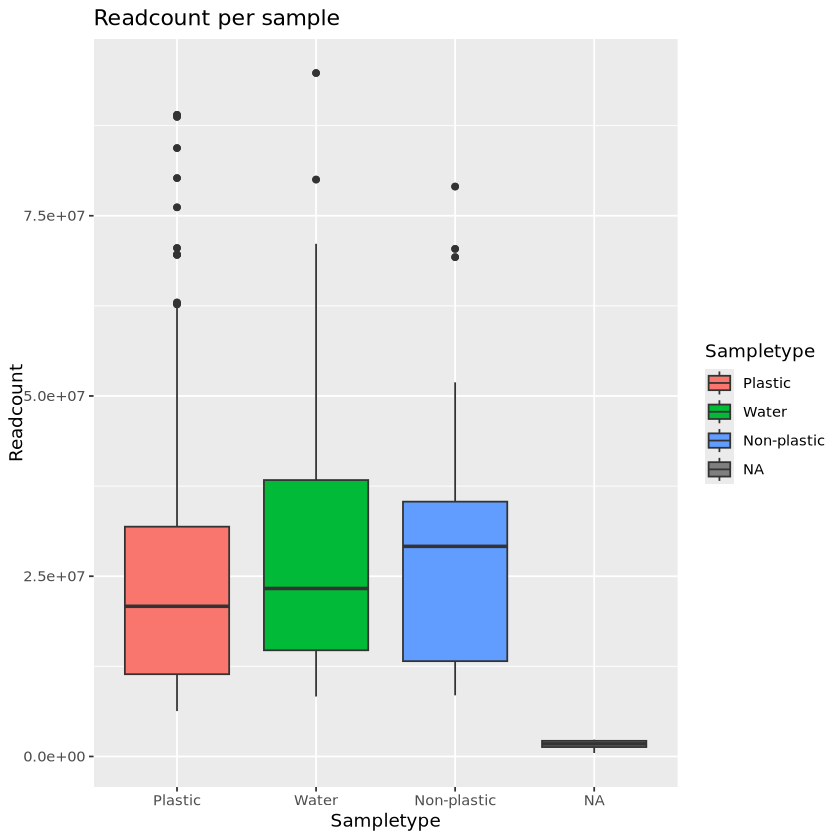

Saving 7 x 7 in image


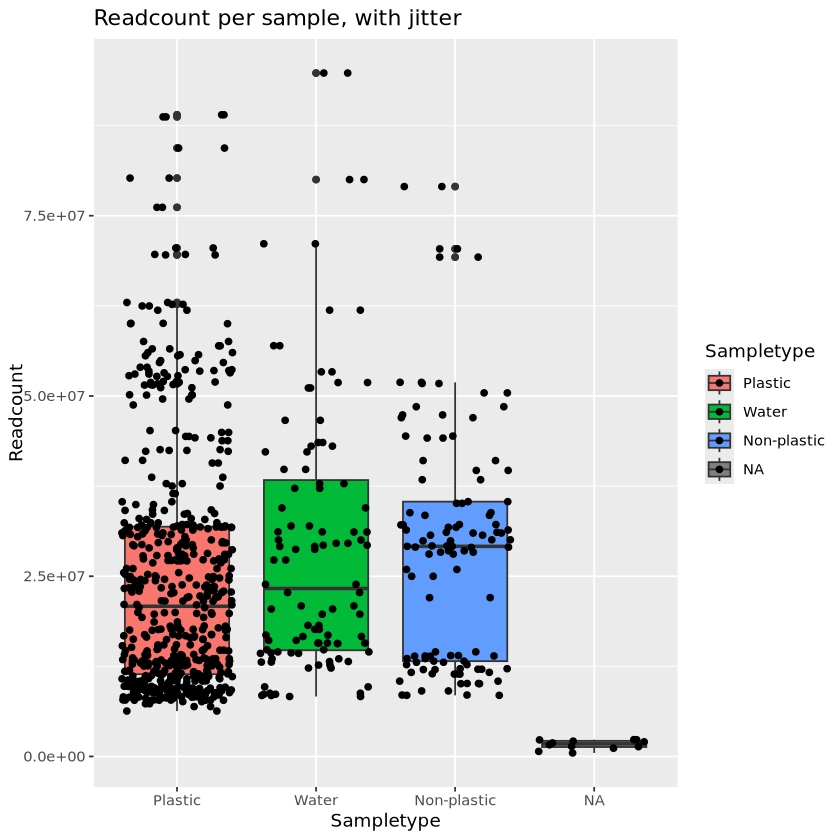

In [8]:
# Gives us a dataframe where row = sample and column = readcount. Also the sample metadata is added.
df_sample_readcount <- df_readcount %>%
    dplyr::select(!Description) %>%
    dplyr::select(contains("_1_val-Mut"))%>%
    pivot_longer(cols = everything(), names_to = "Sample", values_to = "Readcount") %>%
    mutate(Sample = str_remove(Sample, "_1_val-Mut")) %>%
    left_join(sample_metadata, by = join_by(Sample == run_accession)) %>%
    arrange(Sampletype, Substrate) %>%
    mutate(Sampletype = factor(Sampletype, levels = c("Plastic", "Water", "Non-plastic")))

plot_readcount <- df_sample_readcount %>%
    #filter(Readcount < 5000000) %>%
    ggplot(aes(Sampletype, Readcount, fill = Sampletype))+
        geom_boxplot()+
        scale_color_colorblind()
        #geom_violin()

plot_readcount + labs(title = "Readcount per sample")
if (save_plots) ggsave("figs/readcount.png")
plot_readcount + geom_jitter() + labs(title = "Readcount per sample, with jitter")
if (save_plots) ggsave("figs/readcount_jitter.png")

## Inspect readcounts

In [9]:
#df_sample_readcount %>%
#    ggplot(aes(Sample, Readcount, col = Sampletype))+
#        scale_color_brewer(palette = "Paired") + 
#        ylim(c(0, 1e6))+
#        geom_point()
##df_sample_readcount[which(df_sample_readcount$Readcount == min(df_sample_readcount$Readcount)), ]
##dim(df_long_relative)
#
#options(repr.plot.width=7, repr.plot.height=7)
#df_long_relative[which(df_long_relative$Percent_mutation >= 1), ] %>%
#    ggplot(aes(Name, Percent_mutation, col = study_accession, shape = study_accession))+
#        geom_point()+
#        #ylim(c(0, 2))+
#        scale_color_brewer(palette = "Paired")
#
#df_sample_readcount %>%
#    filter(study_accession == "PRJNA318384") %>%
#    ggplot(aes(Sample, Readcount))+
#        geom_point() +
#        ylim(c(0, 1e6))+
#        scale_color_brewer(palette = "Paired")
#df_relative %>%
#    dplyr::select(Description, SRR3401475_1, SRR3401475_2) %>%
#    pivot_longer(contains("SRR"), names_to = "SRR3401475", values_to = "Relative_frequency") %>%
#    ggplot(aes(Description, Relative_frequency, col = SRR3401475))+
#        geom_point()

### Plots mutation percent, relative data


-----------
figure_df <- df_long_relative
-----------


Saving 7 x 7 in image
Warning message:
“Removed 377109 rows containing non-finite outside the scale range (`stat_boxplot()`).”


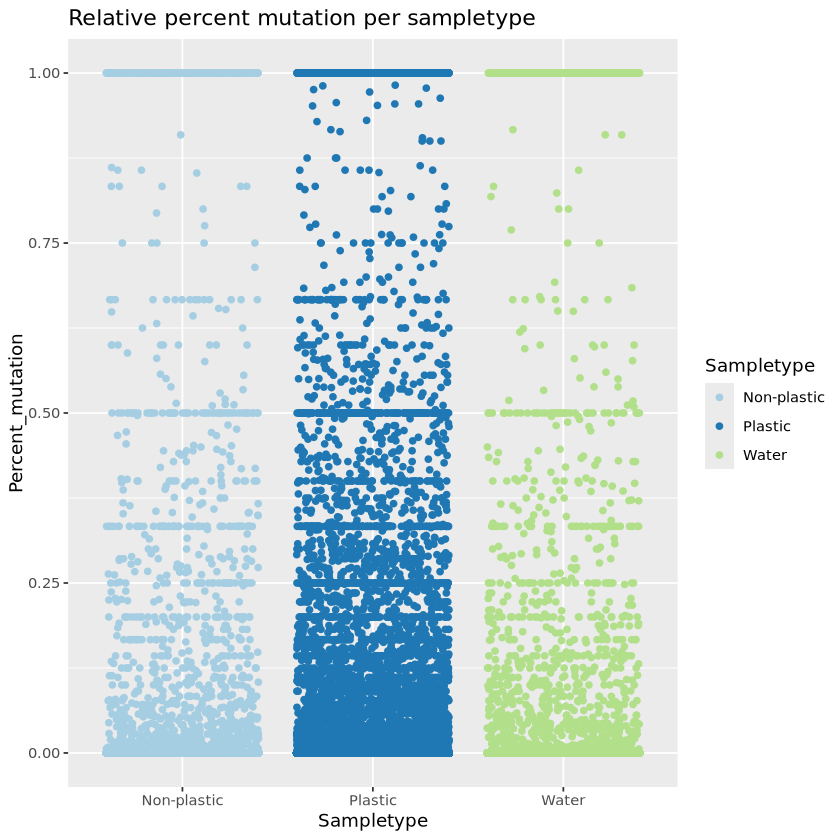

Saving 7 x 7 in image
Warning message:
“Removed 377109 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 377109 rows containing non-finite outside the scale range (`stat_boxplot()`).”


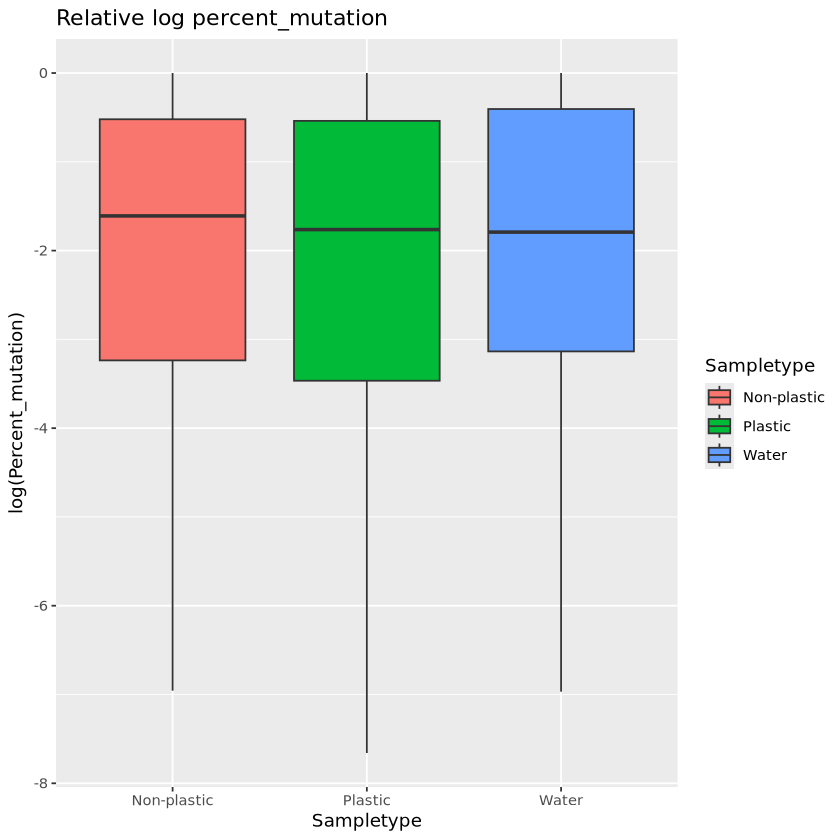

Saving 7 x 7 in image
Warning message:
“Removed 377109 rows containing non-finite outside the scale range (`stat_boxplot()`).”


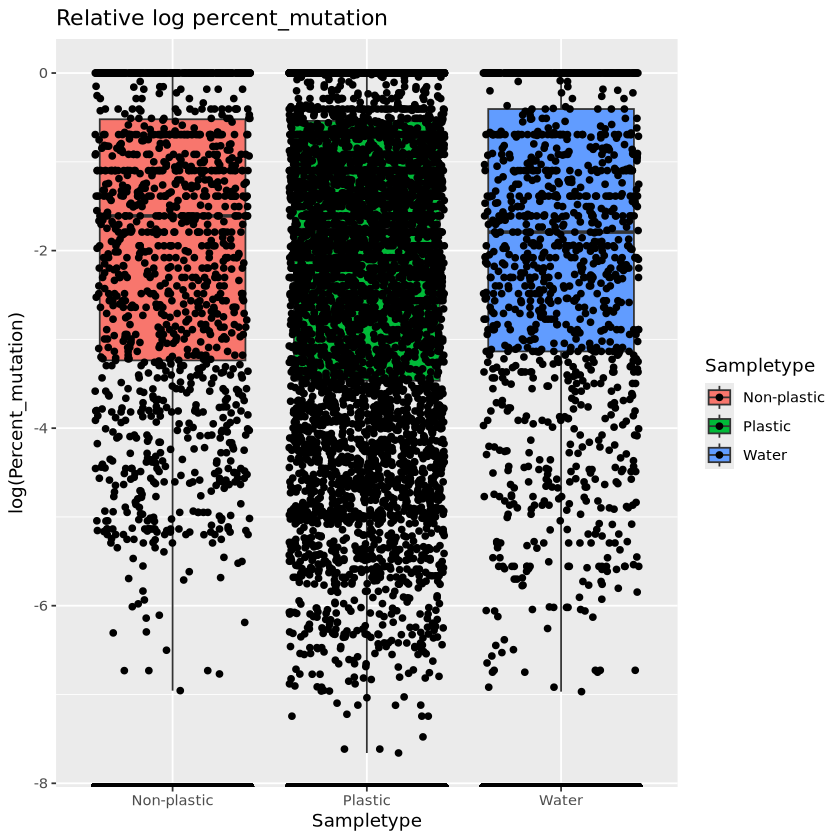

Saving 7 x 7 in image


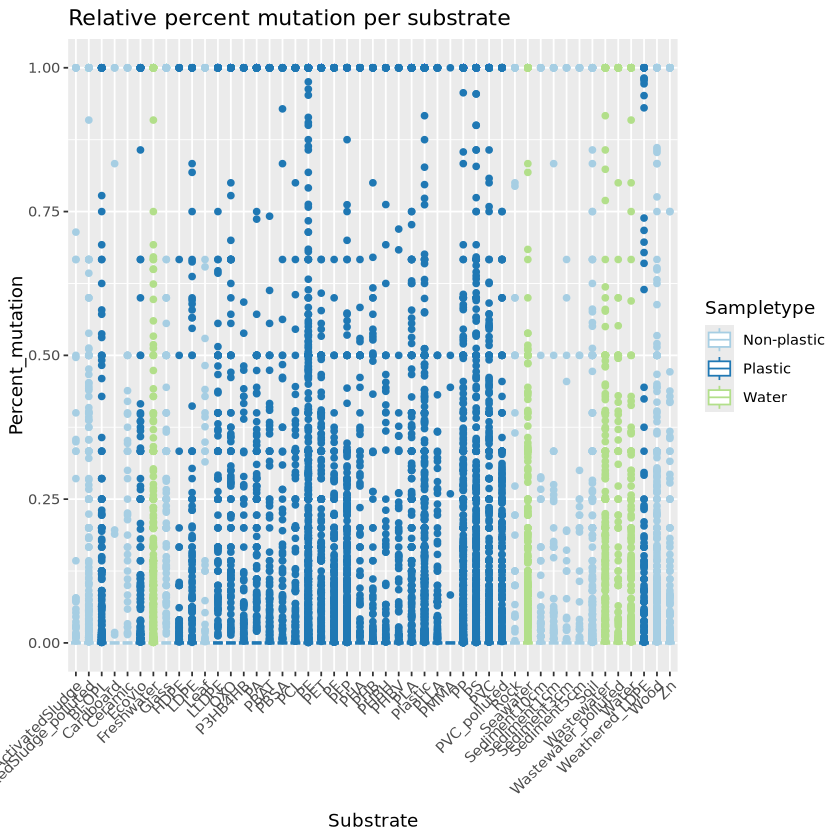

Saving 7 x 7 in image


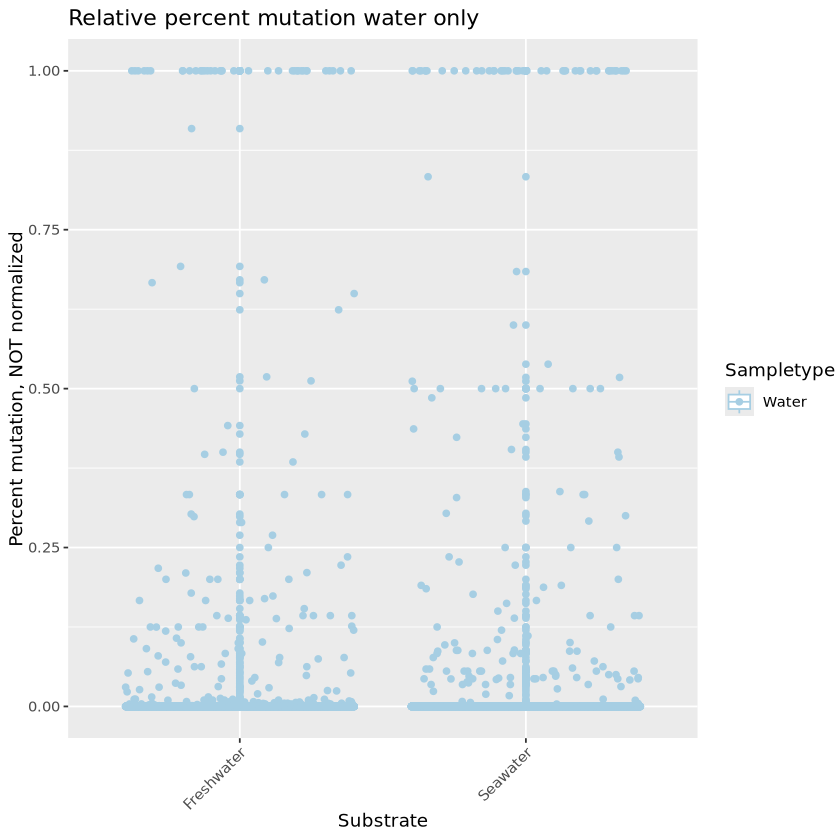

In [10]:
figure_df <- df_long_relative; cat("\n-----------\nfigure_df <- df_long_relative\n-----------\n")

# TILE
#figure_df %>%
#    ggplot(aes(Description, Sample, fill = Percent_mutation))+
#    geom_tile()

# JITTER
figure_df %>%
    ggplot(aes(Sampletype, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_jitter()+
        labs(title = "Relative percent mutation per sampletype")
if (save_plots) ggsave("figs/percent_relative_jitter.png")

# LOG BOXPLOT
plot_box_log <- figure_df %>%
    ggplot(aes(Sampletype, log(Percent_mutation), fill = Sampletype)) + 
        scale_color_brewer(palette = "Paired") + 
        geom_boxplot() +
        labs(title = "Relative log percent_mutation")

plot_box_log
if (save_plots) ggsave("figs/percent_relative_box_log.png")
plot_box_log + geom_jitter()
if (save_plots) ggsave("figs/percent_relative_box_log_jitter.png")

# BOXPLOT SUBSTRATE
plot_substrate <- figure_df %>%
    ggplot(aes(Substrate, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        labs(title = "Relative percent mutation per substrate")
plot_substrate + 
    geom_boxplot()
if (save_plots) ggsave("figs/percent_relative_substrate.png")

# WATER ONLY
figure_df %>%
    filter(Substrate == c("Seawater", "Freshwater")) %>%
    ggplot(aes(Substrate, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_boxplot() +
        geom_jitter() +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        labs(title = "Relative percent mutation water only") + 
        ylab("Percent mutation, NOT normalized")
if (save_plots) ggsave("figs/percent_relative_water.png")

# Microeco

## Using df_relative

In [11]:
# Create dataframes for microeco to use
microeco_otutable <- df_relative %>%
    column_to_rownames("Description") %>%
    # Replace all NA:s with zeros?
    mutate_all(~replace(., is.na(.), 0))


microeco_sampleinfo <- sample_metadata %>%
    dplyr::select(!contains(":")) %>%
    column_to_rownames("Sample")


microeco_taxtable <- df_relative %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession") %>%
    column_to_rownames("Description") %>%
    dplyr::select("Resistance Mechanism", "Drug Class", "AMR Gene Family")
# Taxtable:
# AMR gene family: 47
# Drug Class: 28
# Resistance Mechanism: 6


# Create the microtable-class object 
mt <- microtable$new(otu_table = microeco_otutable, sample_table = microeco_sampleinfo, tax_table = microeco_taxtable)
mt$tidy_dataset()

135 taxa with 0 abundance are removed from the otu_table ...

1 samples with 0 abundance are removed from the otu_table ...



### LEFSE, AMR Gene Family, relative

In [12]:
# Takes ~1 second
lefse_relative <- trans_diff$new(dataset = mt, method = "lefse", group = "Sampletype", lefse_subgroup = NULL, alpha = 0.05, taxa_level = "AMR Gene Family", boots = 999) 

# Not all genes are integers: (since they are all between 0 and 1)
#t1 <- trans_diff$new(dataset = mt, method = "ALDEx2_t", group = "Sampletype", alpha = 0.01) 

No taxa_abund list found. Calculate it with cal_abund function ...

The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

12 taxa found significant ...

After P value adjustment, 5 taxa found significant ...

Minimum LDA score: 3.64021608414213 maximum LDA score: 4.69669118386722

Taxa abundance table is stored in object$res_abund ...

lefse analysis result is stored in object$res_diff ...



Saving 7 x 7 in image
The length of use_number is larger than taxa number in object$diff_data. Use all taxa ...



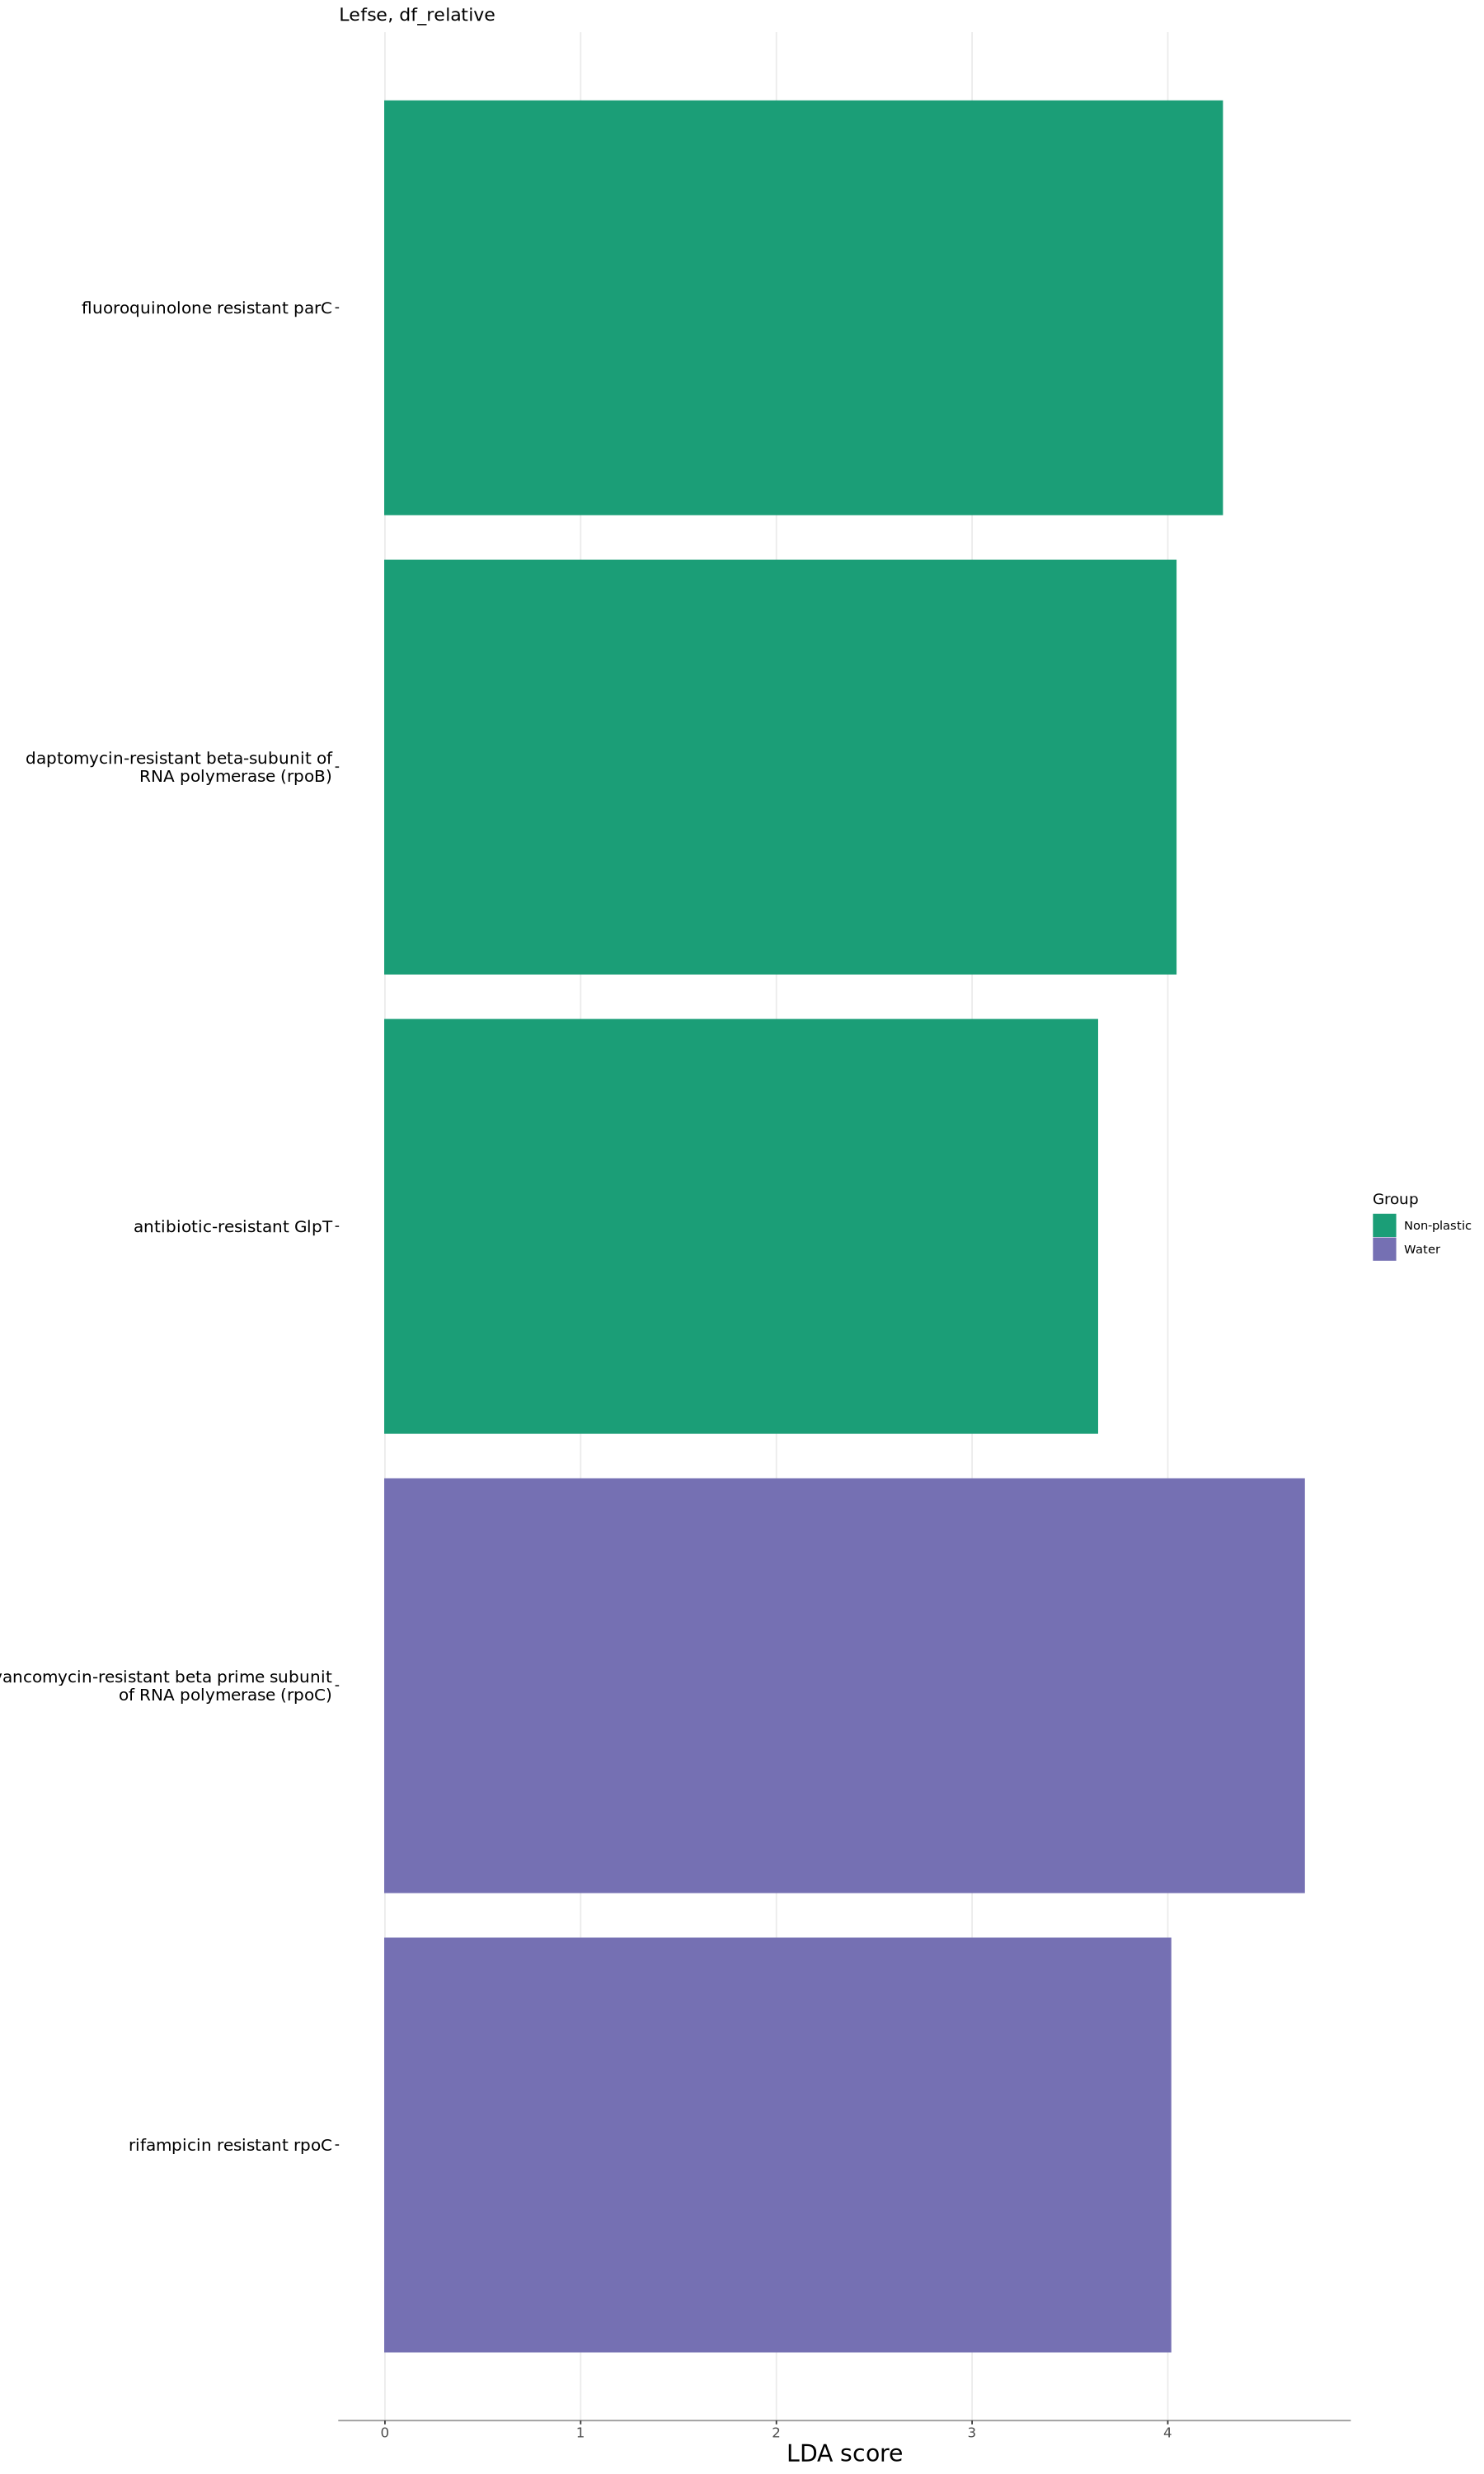

Saving 7 x 7 in image


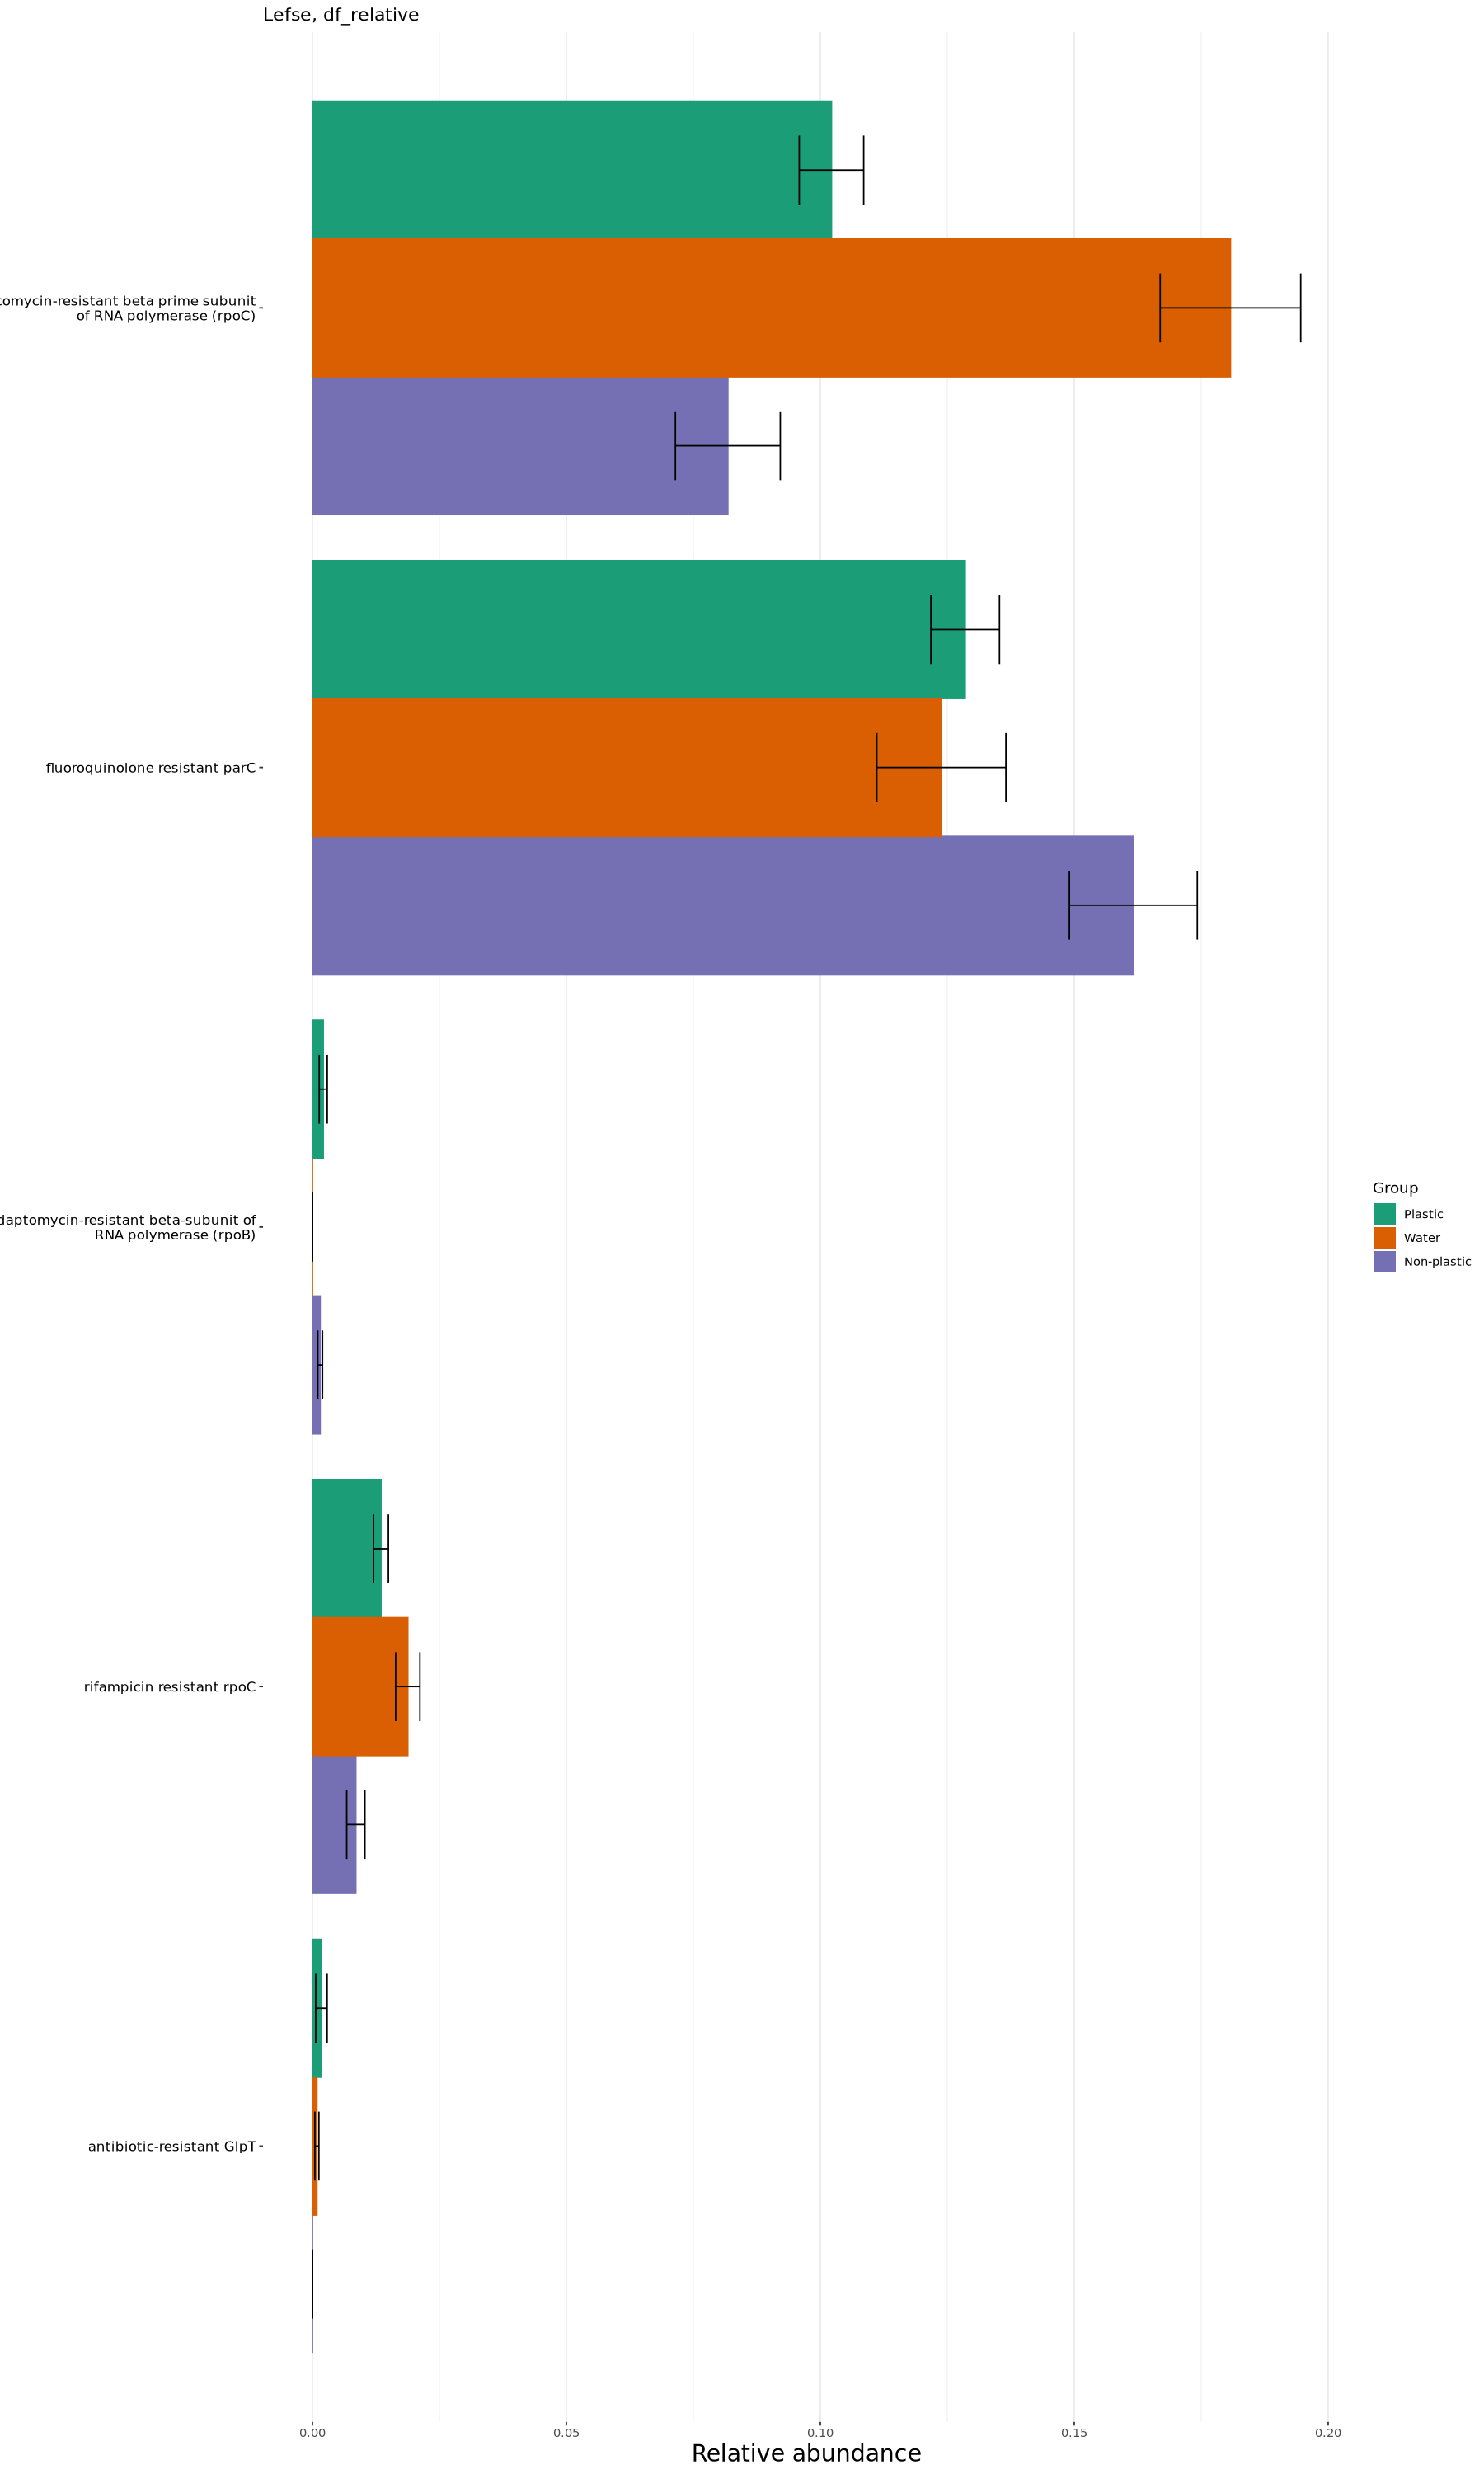

In [13]:
options(repr.plot.width=15, repr.plot.height=25)
lefse_relative$plot_diff_bar(
    group_order = c("Plastic", "Non-plastic", "Water"),
    color_group_map = TRUE,
    threshold = 1
    ) + 
    scale_x_discrete(labels = label_wrap(40)) +
        labs(title = "Lefse, df_relative")
if (save_plots) ggsave("figs/relative_lefse_bar.png")

lefse_relative$plot_diff_abund(
    use_number = 1:30
    ) + 
    scale_x_discrete(labels = label_wrap(40)) +
        labs(title = "Lefse, df_relative")
if (save_plots) ggsave("figs/relative_lefse_abund.png")

options(repr.plot.width=7, repr.plot.height=7)

### Random forest, AMR Gene Family, relative

In [14]:
# Takes ~3 minutes:
if (run_long_functions) {
t_randomforest <- trans_diff$new(dataset = mt, method = "rf", group = "Sampletype", alpha = 0.05, taxa_level = "AMR Gene Family", boots = 999) 

t_randomforest$plot_diff_abund(
    color_group_map = TRUE, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(20))+
    labs(title = "Random forest, relative")
if (save_plots) ggsave("figs/relative_forest_abund.png")
    
t_randomforest$plot_diff_bar(
    color_group_map = TRUE, 
    use_number = 1:100, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(20))+
    labs(title = "Random forest, relative")
if (save_plots) ggsave("figs/relative_forest_bar.png")
}

No taxa_abund list found. Calculate it with cal_abund function ...

The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

12 taxa found significant ...

After P value adjustment, 5 taxa found significant ...

Taxa abundance table is stored in object$res_abund ...

rf analysis result is stored in object$res_diff ...

The length of use_number is larger than taxa number in object$diff_data. Use all taxa ...

Saving 7 x 7 in image
Warning message in geom_bar(stat = "identity", position = position_dodge(), ...):
“Ignoring unknown parameters: `add_sig`”
Saving 7 x 7 in image


## Using df_counts

In [15]:
# Using df_counts instead of the relative data from before
microeco_otutable_counts <- df_counts %>%
    column_to_rownames("Description") %>%
    # Replace all NA:s with zeros, since only done on relative data before
    mutate_all(~replace(., is.na(.), 0))


# Create a new sampleinfo where rownames match columnnames of otu_table
microeco_sampleinfo_counts <- data.frame(Sample_full = names(df_counts)) %>%
    # Get the samplename and type (Mut or WT) for each column
    mutate(
        Type = str_remove(Sample_full, ".*_val-"),
        run_accession = str_remove(Sample_full, "_[12]_val-(Mut|WT)"),
        Sample = str_remove(Sample_full, "_val-(Mut|WT)")
        )%>%
    # Remove extra row which came from 'names'
    filter(Sample_full != "Description") %>%
    # Add the metadata by run_accession
    left_join(x = ., y = sample_metadata, by = join_by(run_accession, Sample)) %>%    
    relocate(Sample_full, Type, Sample, Sampletype, Substrate) %>%
    dplyr::select(-study_accession, -c(Latitude, Longitude), run_accession) %>%
    column_to_rownames("Sample_full")


# Same taxtable as above


#head(microeco_sampleinfo_counts)
#head(microeco_otutable_counts)
#head(microeco_sampleinfo)


# Create the microtable-class object 
mt_counts <- microtable$new(otu_table = microeco_otutable_counts, sample_table = microeco_sampleinfo_counts, tax_table = microeco_taxtable)
mt_counts$tidy_dataset()


1 samples with 0 abundance are removed from the otu_table ...



### Creating paired ALDEx t-test and KW using count data

In [16]:
# Takes ~15 seconds
aldex_t_counts <- trans_diff$new(dataset = mt_counts, method = "ALDEx2_t", by_ID = "Type", group = "Sampletype", taxa_level = "AMR Gene Family", paired.test = TRUE) # filter_thres = 0.0005)?

if (run_long_functions) {
# Takes ~9 minutes
aldex_kw_counts <- trans_diff$new(dataset = mt_counts, method = "ALDEx2_kw", by_ID = "Type", group = "Sampletype", taxa_level = "AMR Gene Family", paired.test = TRUE) # filter_thres = 0.0005)?
}

No taxa_abund list found. Calculate it with cal_abund function ...

The result is stored in object$taxa_abund ...

Total 3 paired group for test ...

Run 1 : Plastic - Water ...


Input features number: 46

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Run 2 : Plastic - Non-plastic ...


Input features number: 45

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Run 3 : Water - Non-plastic ...


Input features number: 28

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Taxa abundance tab

The result is stored in object$taxa_abund ...

Total 3 paired group for test ...

Run 1 : Plastic - Water ...


Input features number: 46

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Run 2 : Plastic - Non-plastic ...


Input features number: 45

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Run 3 : Water - Non-plastic ...


Input features number: 28

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Taxa abundance table is stored in object$res_abund ...

ALDEx2_t analysis result is st

### Plotting paired ALDEx t-test using count data

Reorder taxa according to P.adj in res_diff from low to high ...

Saving 7 x 7 in image


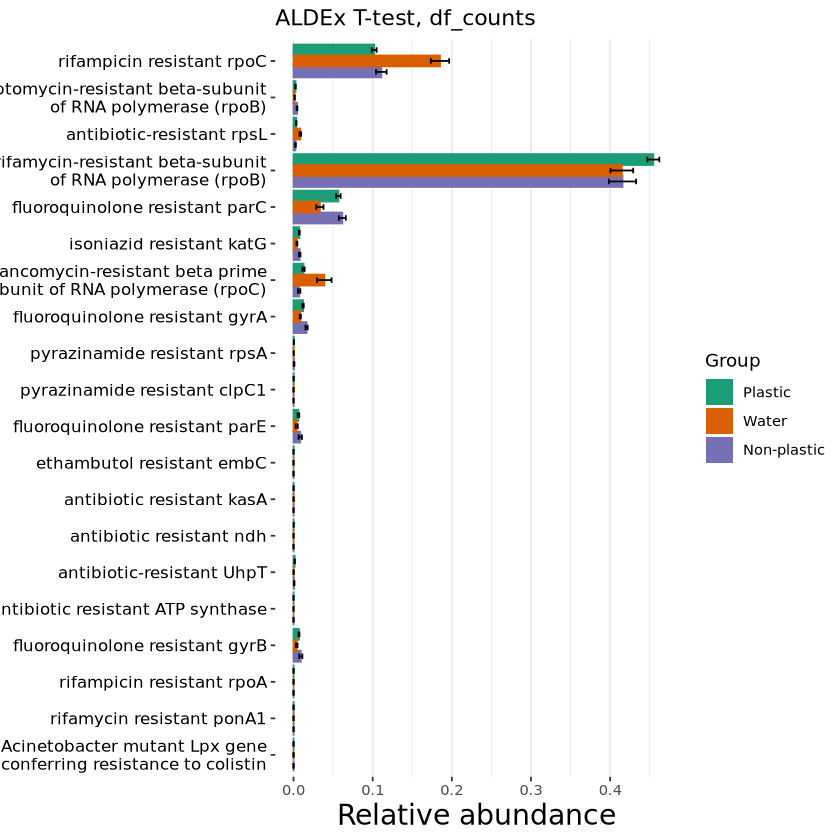

Saving 7 x 7 in image


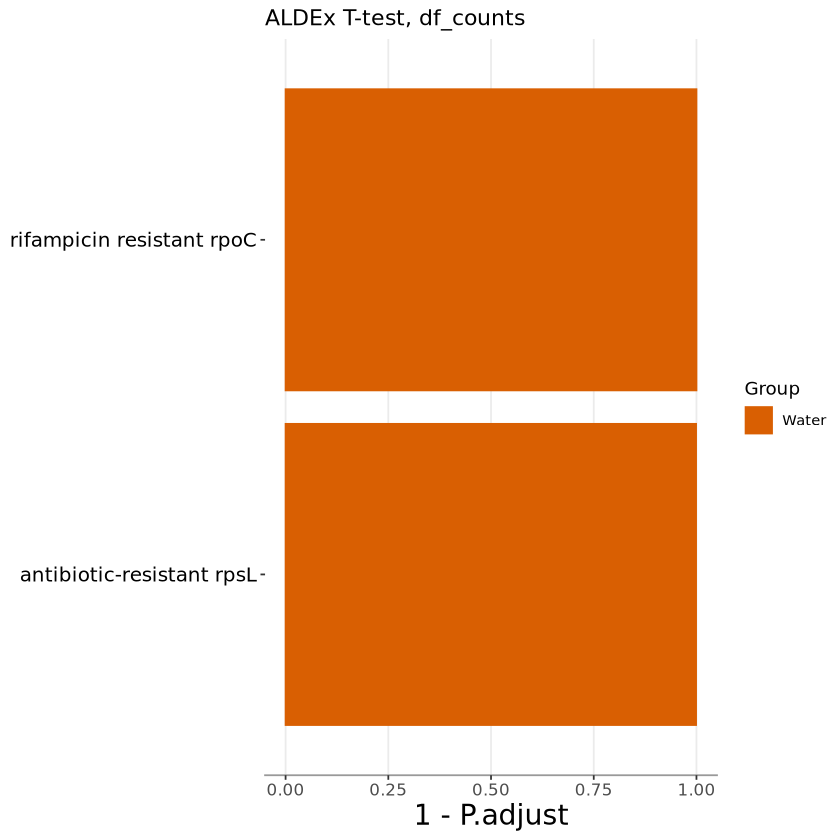

In [17]:
#head(aldex_t_counts$res_diff)
#head(aldex_t_counts$res_abund)

aldex_t_counts$plot_diff_abund(
    use_number = 1:20, # IF 1000 is used, NA is visible
    select_taxa = NULL, 
    simplify_names = TRUE,
    keep_prefix = TRUE,
    group_order = NULL,
    order_x_mean = TRUE,
    coord_flip = TRUE,
    #add_sig = TRUE,
    ytitle_size = 17,
    color_group_map = TRUE
    ) + 
    scale_x_discrete(labels = label_wrap(35)) +
    labs(title = "ALDEx T-test, df_counts")
if (save_plots) ggsave("figs/counts_aldex_t_abund.png") 

aldex_t_counts$plot_diff_bar(
    color_values = RColorBrewer::brewer.pal(8, "Dark2"),
    color_group_map = TRUE,
    use_number = 1:1000,
    threshold = NULL,
    select_group = "Plastic - Water",
#    select_group = "Plastic - Non-plastic",
#    select_group = "Water - Non-plastic",
    keep_prefix = TRUE,
    group_order = NULL,
    coord_flip = TRUE
    ) + 
    scale_x_discrete(labels = label_wrap(30)) +
    labs(title = "ALDEx T-test, df_counts")
if (save_plots) ggsave("figs/counts_aldex_t_bar.png") 

### Plotting paired ALDEx KW using count data

In [18]:
if (run_long_functions) {
aldex_kw_counts$plot_diff_abund(
    use_number = 1:15, 
    select_taxa = NULL, 
    simplify_names = TRUE,
    keep_prefix = TRUE,
    group_order = NULL,
    order_x_mean = TRUE,
    coord_flip = TRUE,
    #add_sig = TRUE,
    ytitle_size = 17,
    color_group_map = TRUE
    ) + 
        scale_x_discrete(labels = label_wrap(50)) +
        labs(title = "ALDEx KW, df_counts")
if (save_plots) ggsave("figs/counts_aldex_kw_abund.png") 
    
aldex_kw_counts$plot_diff_bar(
    color_values = RColorBrewer::brewer.pal(8, "Dark2"),
    color_group_map = TRUE,
    use_number = 1:1000,
    threshold = NULL,
    select_group = "Plastic - Water",
#    select_group = "Plastic - Non-plastic",
#    select_group = "Water - Non-plastic",
    keep_prefix = TRUE,
    group_order = NULL,
    coord_flip = TRUE
    ) + 
        #theme(axis.text.y = element_text(angle = 60))
        scale_x_discrete(labels = label_wrap(50)) +
        labs(title = "ALDEx KW, df_counts")
if (save_plots) ggsave("figs/counts_aldex_kw_bar.png") 
}

Reorder taxa according to P.adj in res_diff from low to high ...

Saving 7 x 7 in image
Saving 7 x 7 in image


### Lefse using count data

No taxa_abund list found. Calculate it with cal_abund function ...

The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

16 taxa found significant ...

After P value adjustment, 11 taxa found significant ...

Start lefse subgroup biomarkers check for Type ...

Remove 5 biomarkers after subgroup check ...

Minimum LDA score: 1.44777429430361 maximum LDA score: 3.1869243176311

Taxa abundance table is stored in object$res_abund ...

lefse analysis result is stored in object$res_diff ...

Saving 7 x 7 in image
The length of use_number is larger than taxa number in object$diff_data. Use all taxa ...



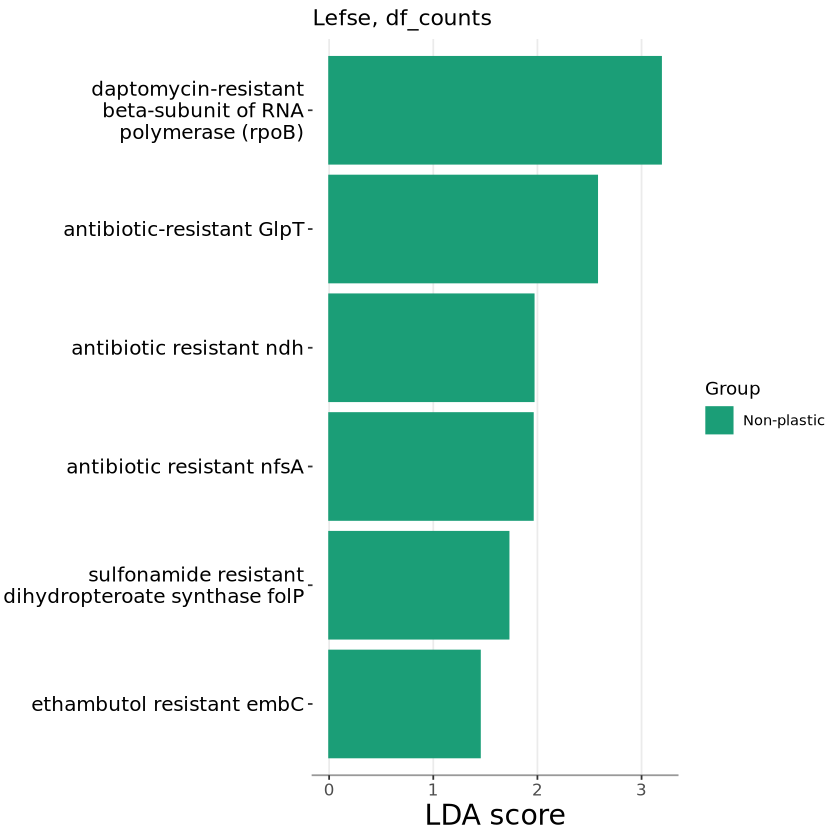

Saving 7 x 7 in image


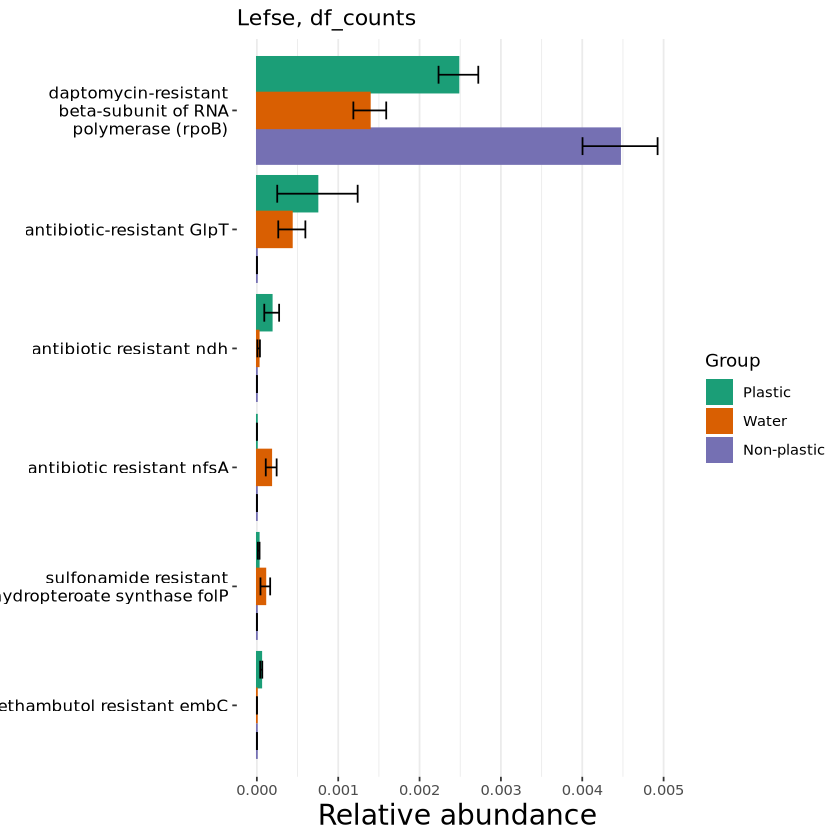

In [19]:
# Takes ~50 seconds
t1_lefse <- trans_diff$new(dataset = mt_counts, method = "lefse", group = "Sampletype", lefse_subgroup = "Type", alpha = 0.01, taxa_level = "AMR Gene Family", boots = 999)

t1_lefse$plot_diff_bar(use_number = 1:100) + #, width = 0.8, group_order = c("CW", "IW", "TW"))
    labs(title = "Lefse, df_counts") + 
    scale_x_discrete(labels = label_wrap(30))
if (save_plots) ggsave("figs/counts_lefse_bar.png") 

t1_lefse$plot_diff_abund(use_number = 1:100) + #, width = 0.8, group_order = c("CW", "IW", "TW"))
    labs(title = "Lefse, df_counts") +
    scale_x_discrete(labels = label_wrap(30))
if (save_plots) ggsave("figs/counts_lefse_abund.png") 

# From LEFSE, AMR Gene Family, relative:
# Takes ~1 second
#lefse_norm <- trans_diff$new(dataset = mt, method = "lefse", group = "Sampletype", alpha = 0.05, lefse_subgroup = NULL, taxa_level = "AMR Gene Family", boots = 999) 
#
## Not all genes are integers: (since they are all between 0 and 1)
##t1 <- trans_diff$new(dataset = mt, method = "ALDEx2_t", group = "Sampletype", alpha = 0.01) 
#
#lefse_norm$plot_diff_bar(
#    group_order = c("Plastic", "Non-plastic", "Water"),
#    color_group_map = TRUE,
#    threshold = 1
#    ) + 
#    scale_x_discrete(labels = label_wrap(30)) +
#        labs(title = "Lefse, df_relative")
#
#lefse_norm$plot_diff_abund(
#    use_number = 1:30
#    ) + 
#    scale_x_discrete(labels = label_wrap(30)) +
#        labs(title = "Lefse, df_relative")

### Random forest using count data

In [20]:
if (run_long_functions) {
# Takes ~15 minutes
t_randomforest_counts <- trans_diff$new(dataset = mt_counts, method = "rf", group = "Sampletype", alpha = 0.05, taxa_level = "AMR Gene Family", boots = 999) 

options(repr.plot.width=15, repr.plot.height=5)
t_randomforest_counts$plot_diff_abund(
    color_group_map = TRUE, 
    add_sig = TRUE,
    coord_flip = FALSE,
    ) +
    scale_x_discrete(labels = label_wrap(23))+
    labs(title = "Random forest, counts")
if (save_plots) ggsave("figs/counts_rforest_abund.png") 

options(repr.plot.width=15, repr.plot.height=10)
t_randomforest_counts$plot_diff_bar(
    color_group_map = TRUE, 
    use_number = 1:100, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(35))+
    labs(title = "Random forest, counts")+
    geom_signif()
if (save_plots) ggsave("figs/counts_rforest_bar.png") 
}

No taxa_abund list found. Calculate it with cal_abund function ...

The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

27 taxa found significant ...

After P value adjustment, 25 taxa found significant ...

Taxa abundance table is stored in object$res_abund ...

rf analysis result is stored in object$res_diff ...

Saving 7 x 7 in image
Warning message in geom_bar(stat = "identity", position = position_dodge(), ...):
“Ignoring unknown parameters: `add_sig`”
Saving 7 x 7 in image


# Wilcoxon rank sum tests

`summarise()` has grouped output by 'Sampletype'. You can override using the `.groups`
argument.
Saving 7 x 7 in image



	Wilcoxon signed rank test with continuity correction

data:  genes_mean_plastic$Mean and genes_mean_water$Mean
V = 38134, p-value = 5.643e-05
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 4.041394e-05 2.244218e-04
sample estimates:
(pseudo)median 
  0.0001266451 



	Wilcoxon signed rank test with continuity correction

data:  genes_mean_plastic$Mean and genes_mean_nonplastic$Mean
V = 39044, p-value = 0.0002785
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon signed rank test with continuity correction

data:  genes_mean_nonplastic$Mean and genes_mean_water$Mean
V = 12213, p-value = 0.6768
alternative hypothesis: true location shift is not equal to 0


`summarise()` has grouped output by 'Sampletype'. You can override using the `.groups`
argument.


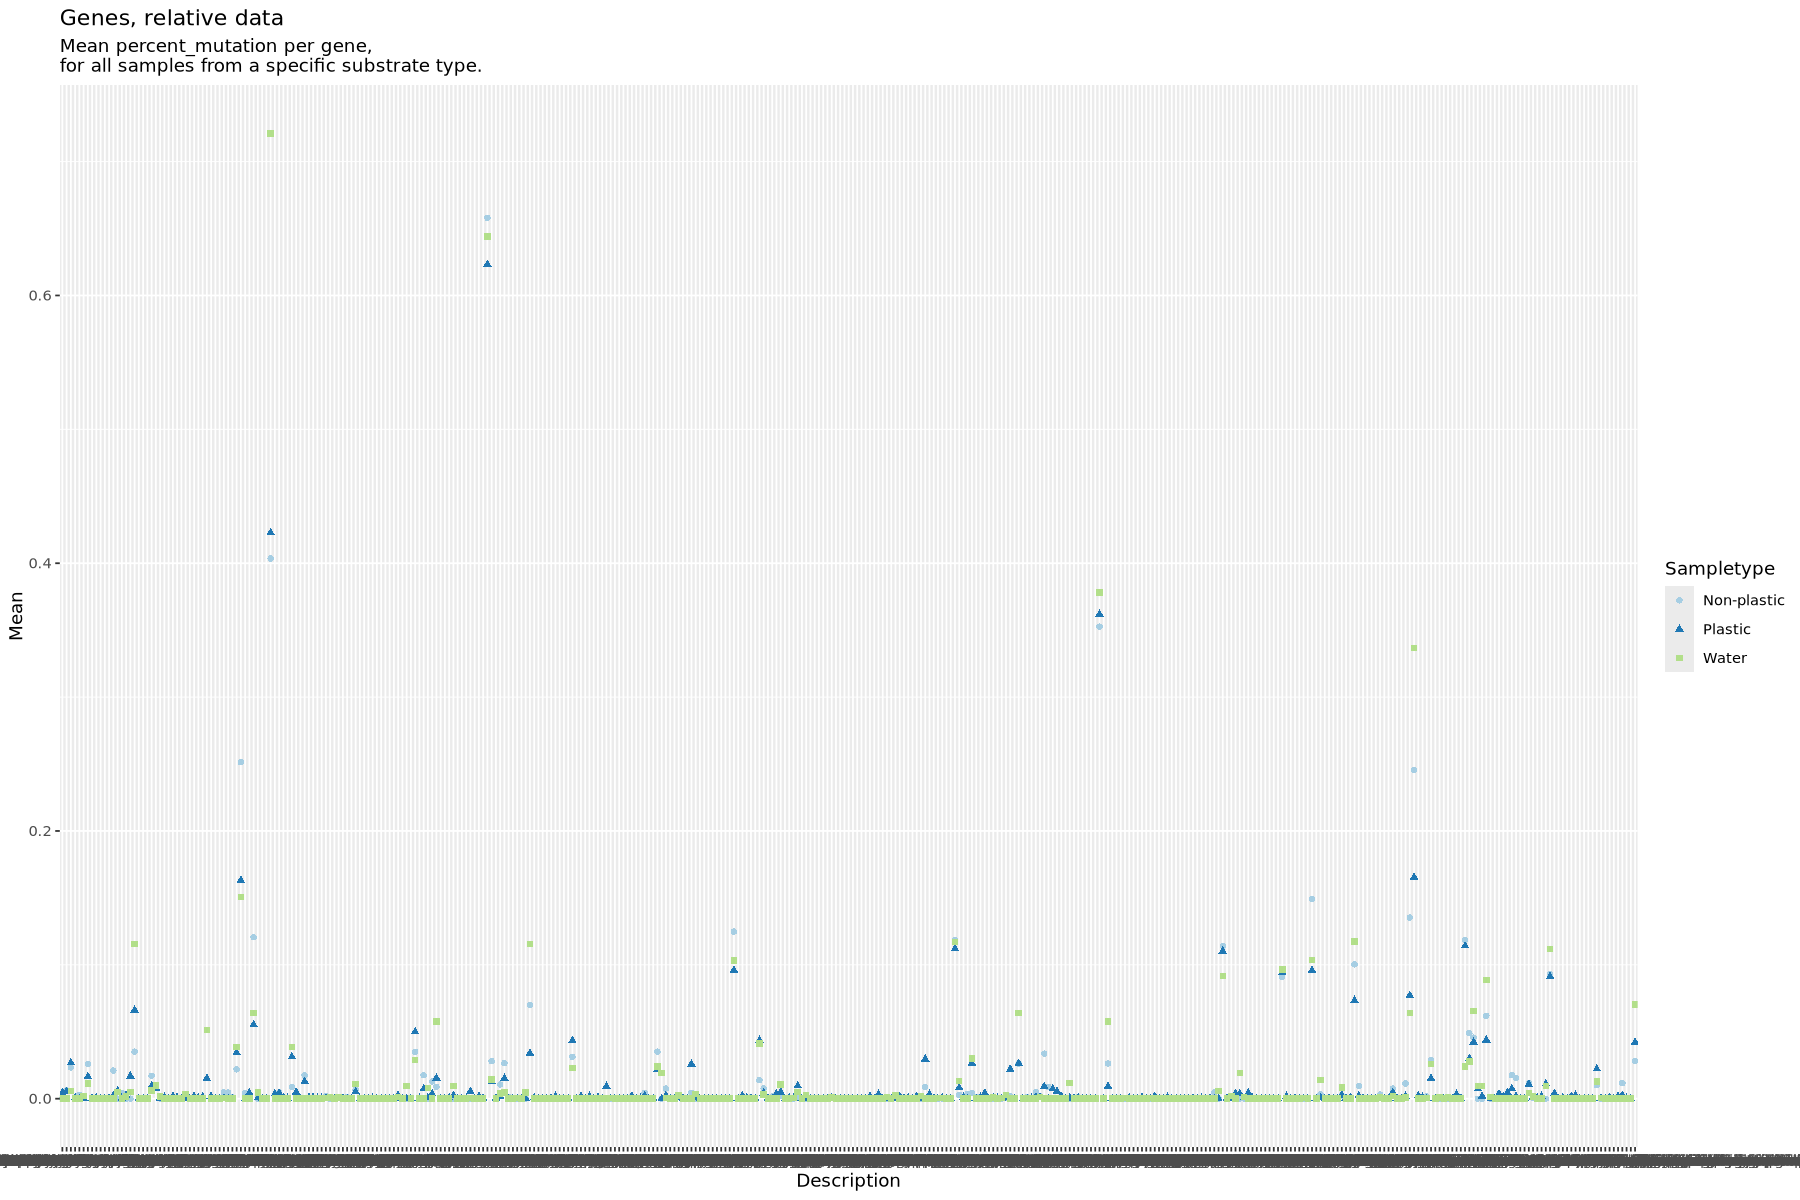

Saving 7 x 7 in image



	Wilcoxon rank sum test with continuity correction

data:  samples_mean_plastic$Mean and samples_mean_water$Mean
W = 22194, p-value = 0.0004943
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -0.0031930262 -0.0009385673
sample estimates:
difference in location 
           -0.00203436 



	Wilcoxon rank sum test with continuity correction

data:  samples_mean_plastic$Mean and samples_mean_nonplastic$Mean
W = 27347, p-value = 0.04731
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  samples_mean_nonplastic$Mean and samples_mean_water$Mean
W = 5304, p-value = 0.1801
alternative hypothesis: true location shift is not equal to 0


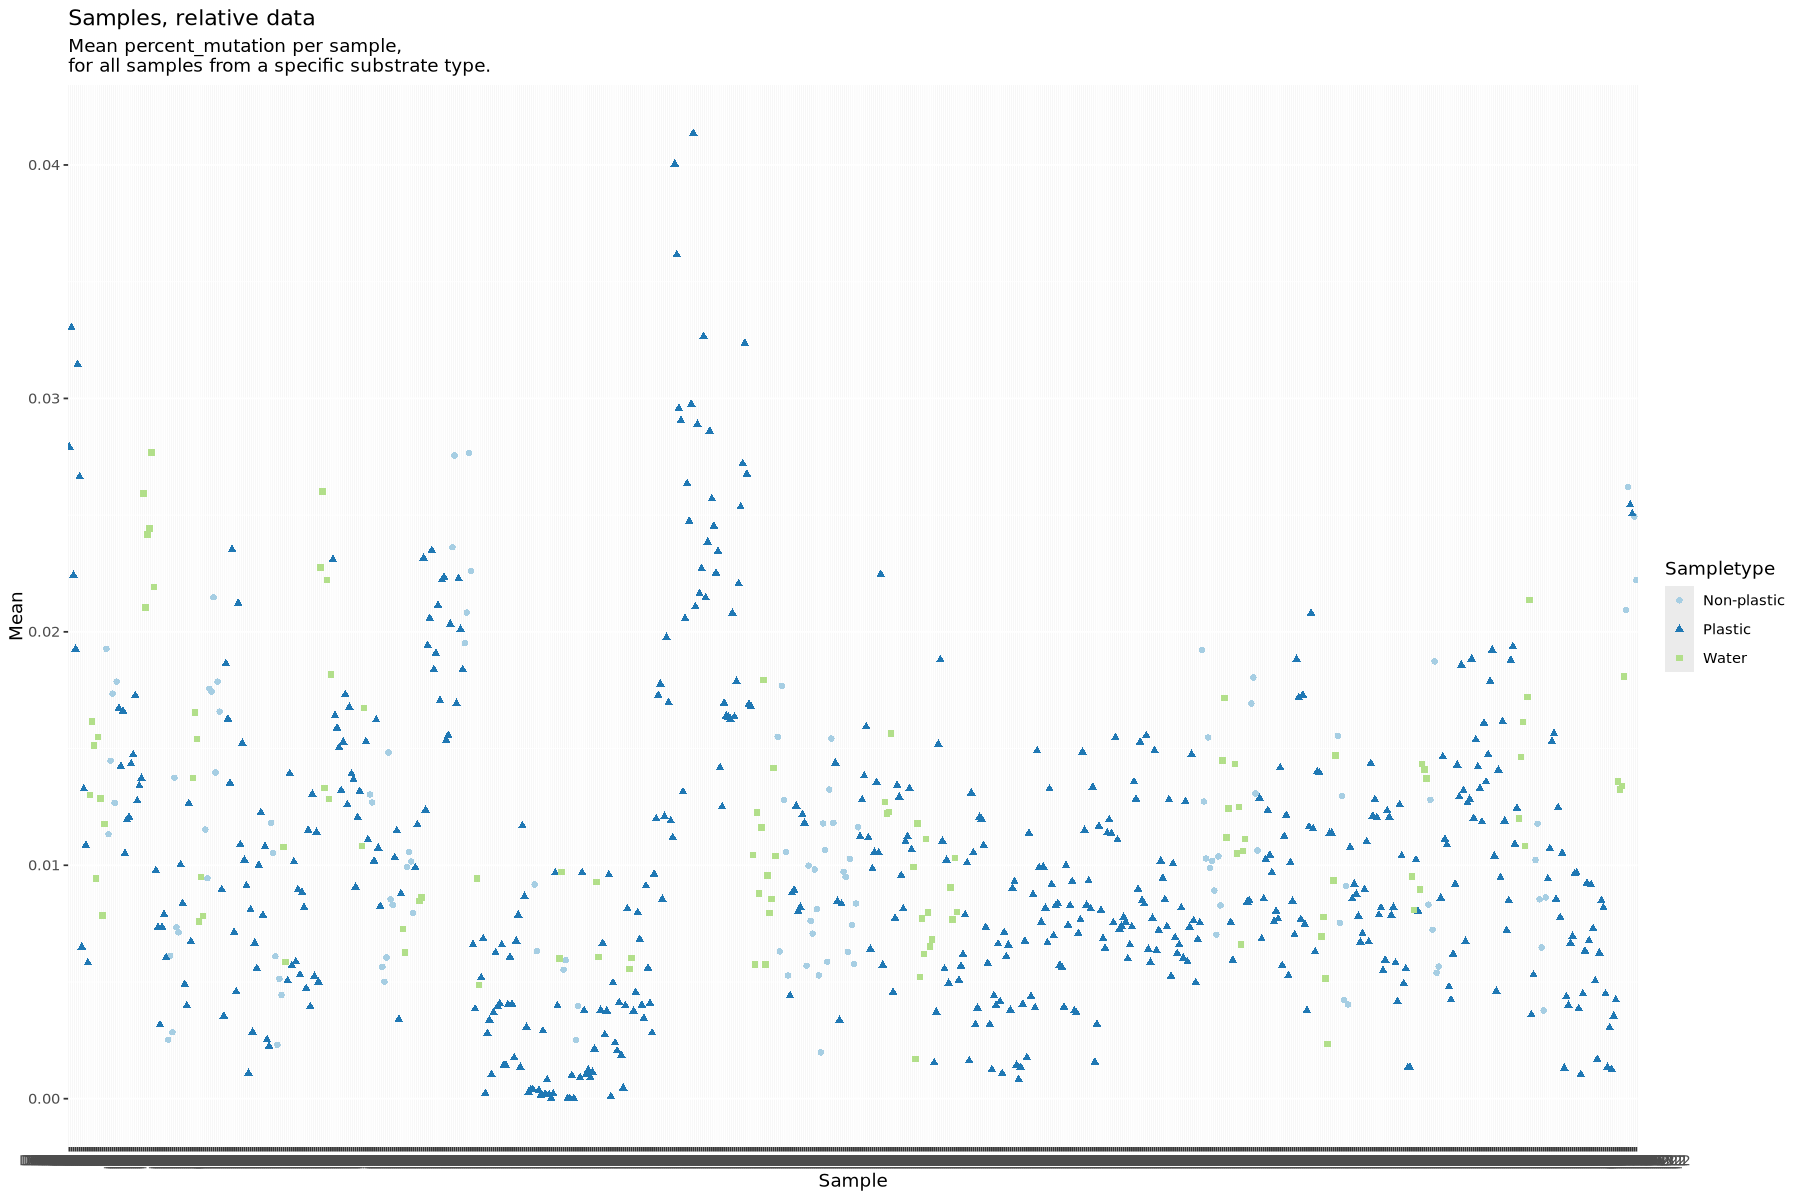

In [21]:
#GENES
# Calculating the mean value for each gene in a specific substrate type
df_mean_percent_genes <- df_long_relative %>%
    filter(!is.na(Percent_mutation)) %>%
    filter(Mutations != "Wildtype") %>%
    group_by(Sampletype, Description) %>%
    summarise(Mean = mean(Percent_mutation))

#df_mean_percent_genes

plot_mean_genes <- df_mean_percent_genes %>% 
    ggplot(aes(Description, Mean, col = Sampletype, shape = Sampletype)) + 
        geom_point() +
        scale_color_brewer(palette = "Paired")+
        labs(title = "Genes, relative data",
        subtitle = "Mean percent_mutation per gene, \nfor all samples from a specific substrate type.")

plot_mean_genes
if (save_plots) ggsave("figs/mean_genes_relative.png")
#print(df_mean_percent_genes, n = Inf)

genes_mean_plastic <- filter(df_mean_percent_genes, Sampletype == "Plastic")
genes_mean_water <- filter(df_mean_percent_genes, Sampletype == "Water")
genes_mean_nonplastic <- filter(df_mean_percent_genes, Sampletype == "Non-plastic")

# There are an equal number of samples in each group, and they occur in the same
# order, can compare between samples.
wilcox.test(x = genes_mean_plastic$Mean,
            y = genes_mean_water$Mean, 
            paired = TRUE,
            conf.int = TRUE)
wilcox.test(x = genes_mean_plastic$Mean,
            y = genes_mean_nonplastic$Mean, 
            paired = TRUE)
wilcox.test(x = genes_mean_nonplastic$Mean,
            y = genes_mean_water$Mean, 
            paired = TRUE)


# SAMPLES
# Calculating the mean value for each sample in a specific substrate type
df_mean_percent_samples <- df_long_relative %>%
    filter(!is.na(Percent_mutation)) %>%
    filter(Mutations != "Wildtype") %>%
    group_by(Sampletype, Sample) %>%
    summarise(Mean = mean(Percent_mutation))

#df_mean_percent_samples

plot_mean_samples <- df_mean_percent_samples %>% 
    ggplot(aes(Sample, Mean, col = Sampletype, shape = Sampletype)) + 
        geom_point() +
        scale_color_brewer(palette = "Paired") + 
    labs(title = "Samples, relative data",
         subtitle = "Mean percent_mutation per sample, \nfor all samples from a specific substrate type.")

plot_mean_samples
if (save_plots) ggsave("figs/mean_samples_relative.png")
#print(df_mean_percent_samples, n = Inf)

samples_mean_plastic <- filter(df_mean_percent_samples, Sampletype == "Plastic")
samples_mean_water <- filter(df_mean_percent_samples, Sampletype == "Water")
samples_mean_nonplastic <- filter(df_mean_percent_samples, Sampletype == "Non-plastic")

# There are not an equal number of samples per group:
#dim(samples_mean_plastic)
#dim(samples_mean_water)
#dim(samples_mean_nonplastic)
wilcox.test(x = samples_mean_plastic$Mean,
            y = samples_mean_water$Mean, 
            conf.int = TRUE)
wilcox.test(x = samples_mean_plastic$Mean,
            y = samples_mean_nonplastic$Mean)
wilcox.test(x = samples_mean_nonplastic$Mean,
            y = samples_mean_water$Mean)


## Plot p-values

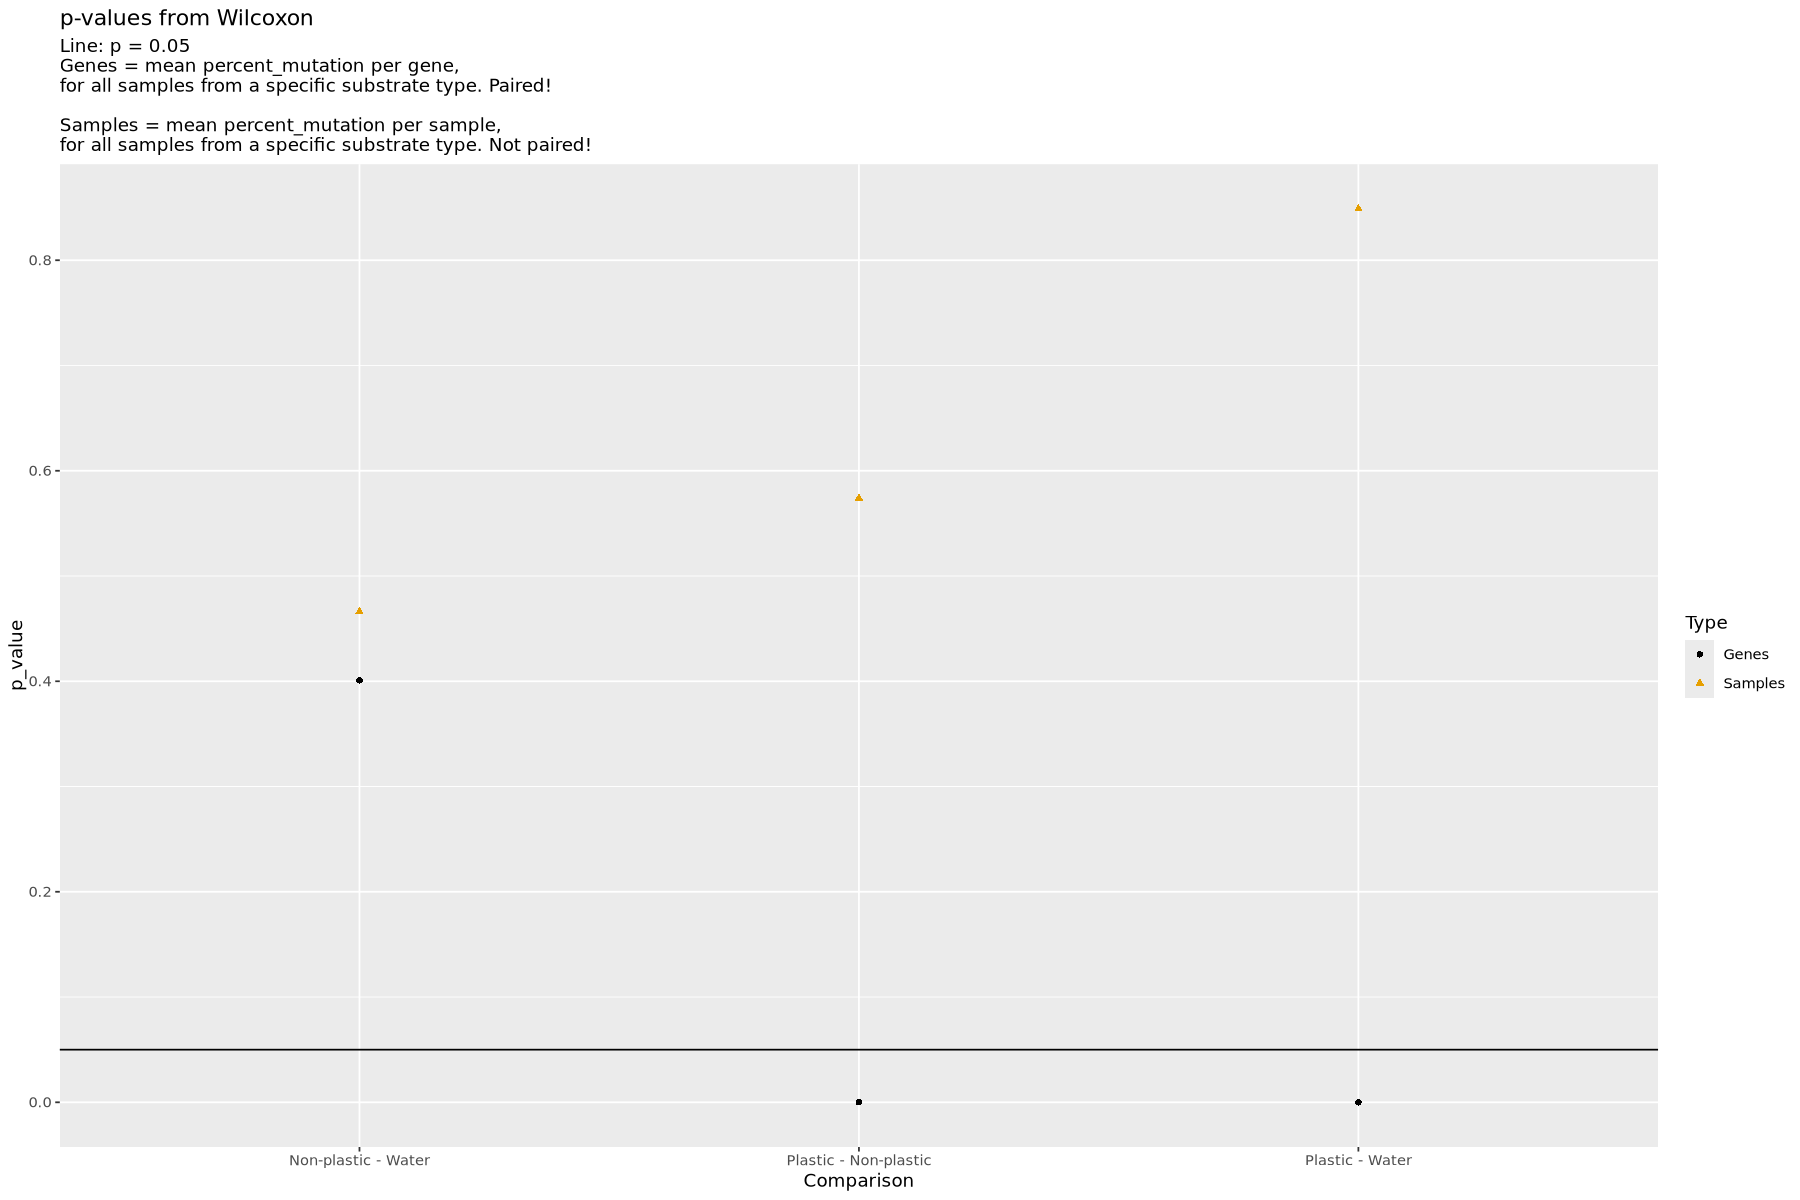

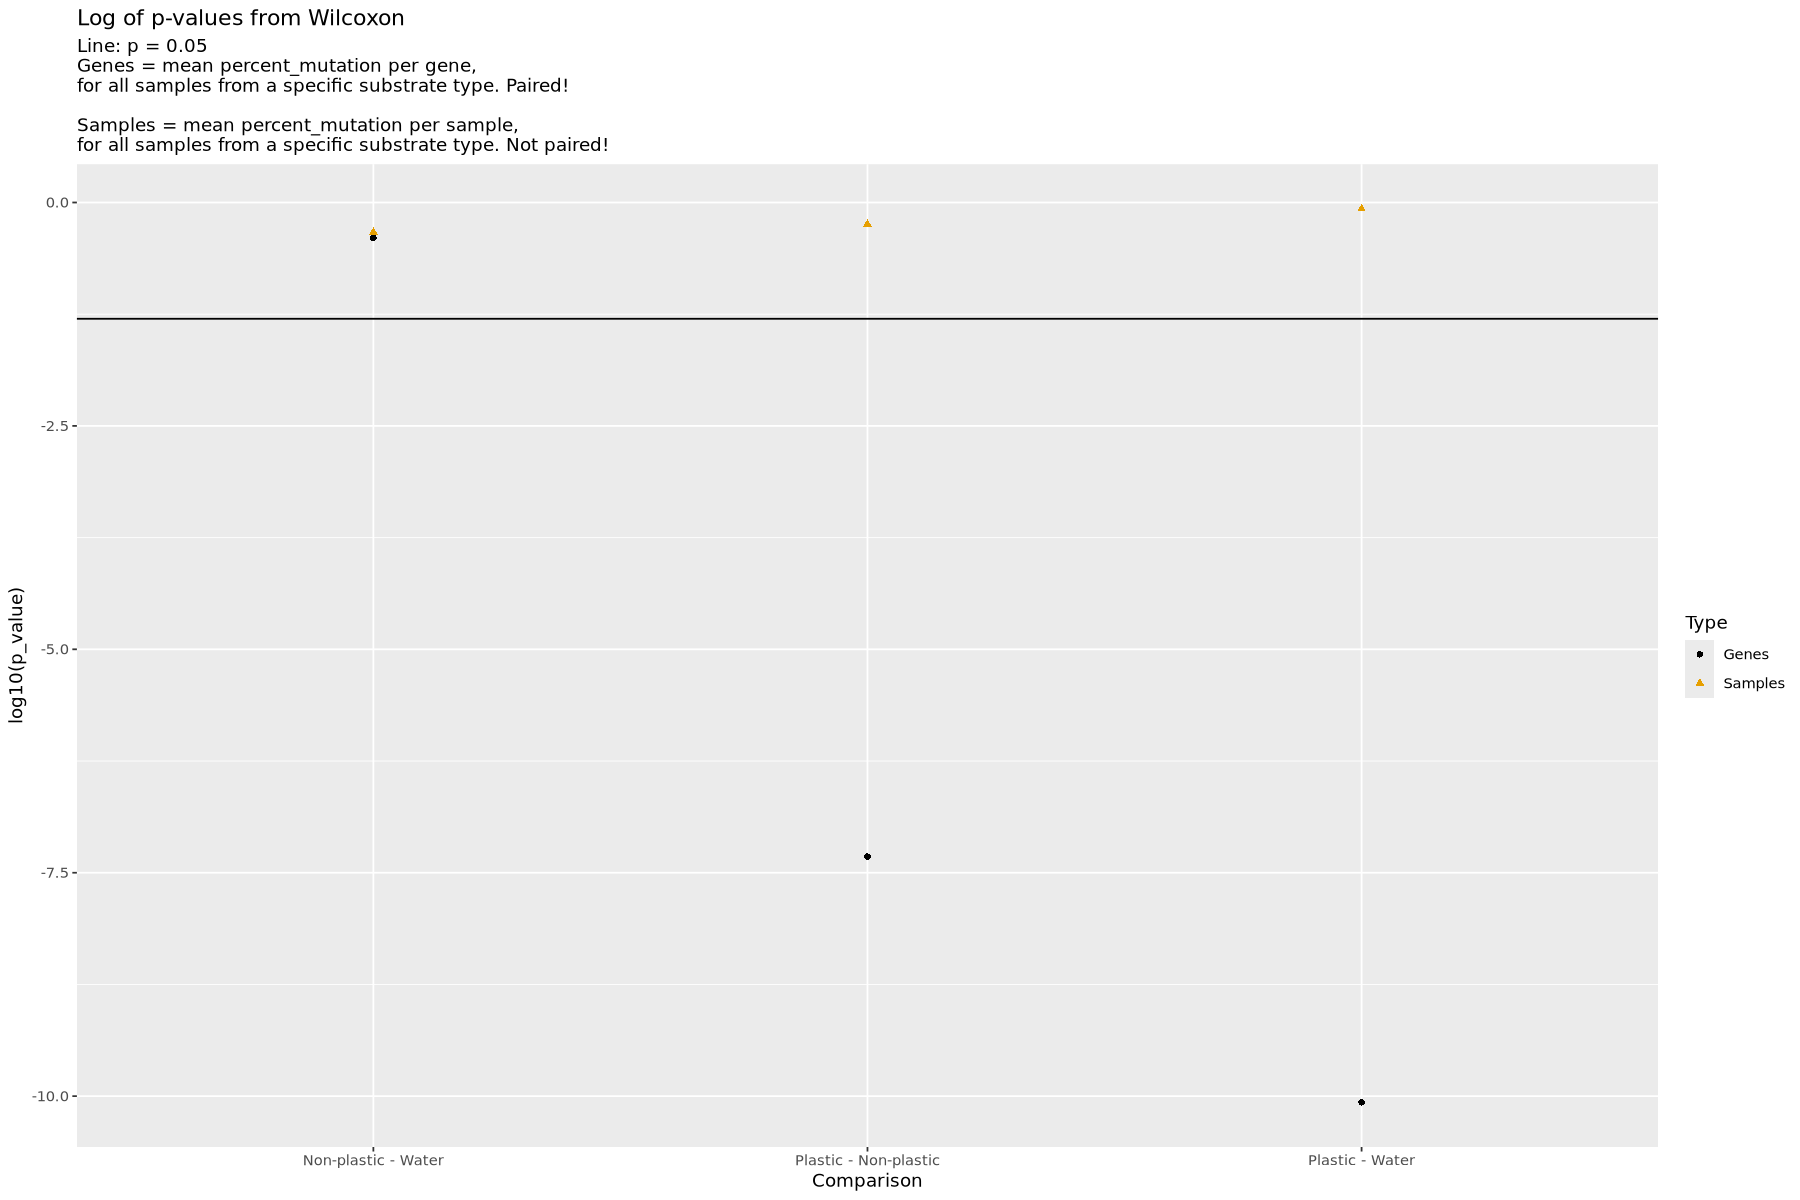

In [22]:
# Genes:
# 8.53e-11 # Plastic - Water
# 4.793e-08 # Plastic - Non-plastic
# 0.4009 # Nonplastic - Water

# Samples:
# 0.8488 # Plastic - Water
# 0.5738 # Plastic - Non-plastic
# 0.4662 # Nonplastic - Water

p_values <- data.frame(Comparison = c("Plastic - Water", "Plastic - Non-plastic", "Non-plastic - Water"),
           Genes = c(8.53e-11, 4.793e-08, 0.4009), 
           Samples = c(0.8488, 0.5738, 0.4662)) %>% 
    pivot_longer(!Comparison, names_to = "Type", values_to = "p_value")

# NORMAL
p_values %>%
    ggplot(aes(Comparison, p_value, col = Type, shape = Type))+
       #scale_color_brewer(palette = "Paired") + 
       scale_color_colorblind() +
       geom_point()+
       geom_hline(yintercept = 0.05) + 
       labs(title = "p-values from Wilcoxon",
            subtitle = "Line: p = 0.05\nGenes = mean percent_mutation per gene, \nfor all samples from a specific substrate type. Paired!\n\nSamples = mean percent_mutation per sample, \nfor all samples from a specific substrate type. Not paired!")

# LOG
p_values %>%
    ggplot(aes(Comparison, log10(p_value), col = Type, shape = Type))+
       #scale_color_brewer(palette = "Paired") + 
       scale_color_colorblind() +
       geom_point()+
       geom_hline(yintercept = log10(0.05)) + 
       labs(title = "Log of p-values from Wilcoxon",
       subtitle = "Line: p = 0.05\nGenes = mean percent_mutation per gene, \nfor all samples from a specific substrate type. Paired!\n\nSamples = mean percent_mutation per sample, \nfor all samples from a specific substrate type. Not paired!")

# TaxonomyTest

In [23]:
metaxa_dc <- read_tsv("storeDir/MetaxaQR_dc/collected_data_unique_run_id.txt", show_col_types = FALSE) %>%
    rename_at(vars(ends_with('_unique_run_id')), ~ str_remove(., "\\_unique_run_id")) %>%
    # Split the taxa into columns for KronaTools to use and place them last.
    separate_wider_delim(Taxa, delim = ";", names = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus"), cols_remove = FALSE) %>%
    relocate(c("Taxa", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus"), .after = everything())

In [24]:
metaxa_dc %>%
    dplyr::select(DRR528402, Taxa:Genus) %>%
    head()
    #write_tsv(file = "metaxa_dc_DRR528402.tsv")

DRR528402,Taxa,Kingdom,Phylum,Class,Order,Family,Genus
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
0,Archaea;Aenigmarchaeota;Aenigmarchaeia;Aenigmarchaeales;Candidatus Aenigmarchaeum;Unclassified Candidatus Aenigmarchaeum,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,Candidatus Aenigmarchaeum,Unclassified Candidatus Aenigmarchaeum
0,Archaea;Aenigmarchaeota;Aenigmarchaeia;Aenigmarchaeales;Unclassified Aenigmarchaeales;,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,Unclassified Aenigmarchaeales,
0,Archaea;Aenigmarchaeota;Aenigmarchaeia;Aenigmarchaeales;uncultured archaeon;Unclassified uncultured archaeon,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,uncultured archaeon,Unclassified uncultured archaeon
0,Archaea;Aenigmarchaeota;Aenigmarchaeia;Unclassified Aenigmarchaeia;;,Archaea,Aenigmarchaeota,Aenigmarchaeia,Unclassified Aenigmarchaeia,,
0,Archaea;Aenigmarchaeota;Deep Sea Euryarchaeotic GroupDSEG;Unclassified Deep Sea Euryarchaeotic GroupDSEG;;,Archaea,Aenigmarchaeota,Deep Sea Euryarchaeotic GroupDSEG,Unclassified Deep Sea Euryarchaeotic GroupDSEG,,
0,Archaea;Aenigmarchaeota;Deep Sea Euryarchaeotic GroupDSEG;uncultured archaeon;Unclassified uncultured archaeon;,Archaea,Aenigmarchaeota,Deep Sea Euryarchaeotic GroupDSEG,uncultured archaeon,Unclassified uncultured archaeon,


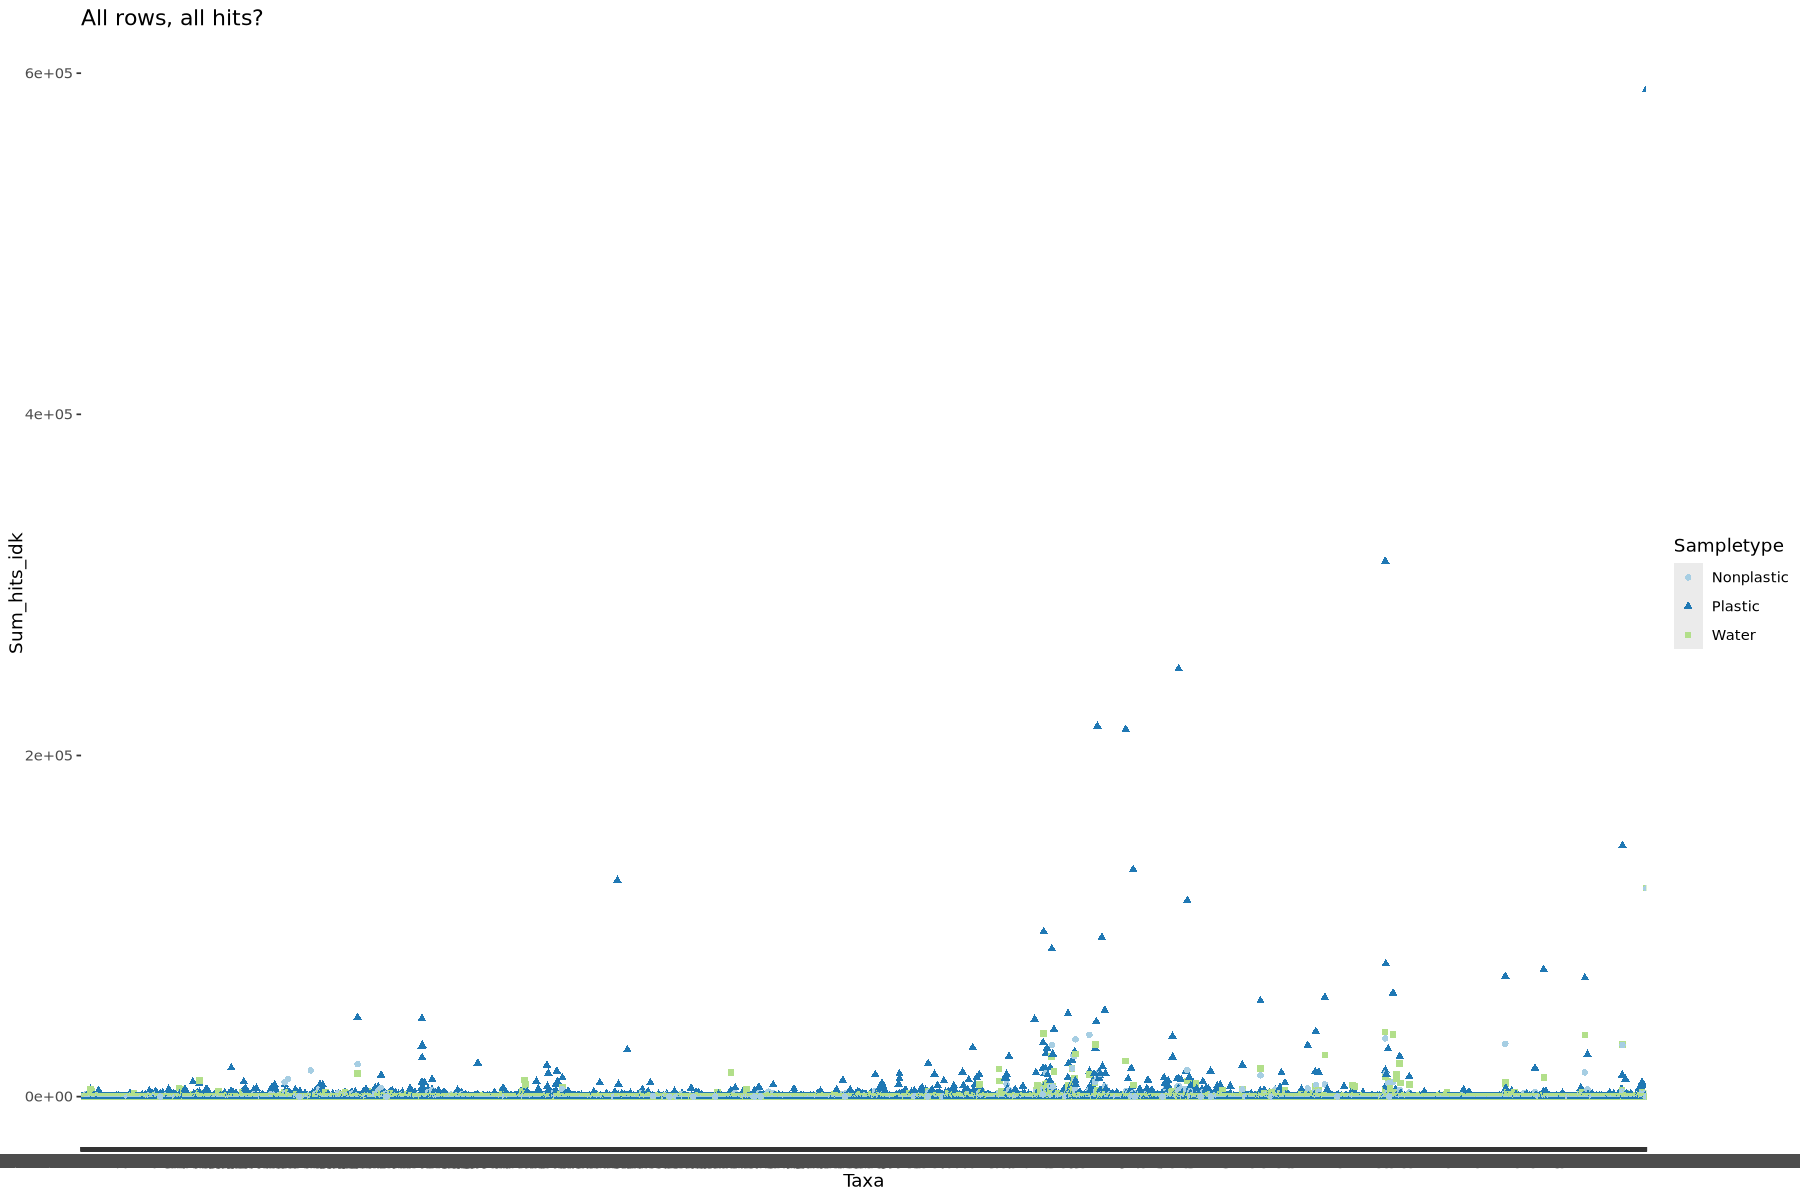

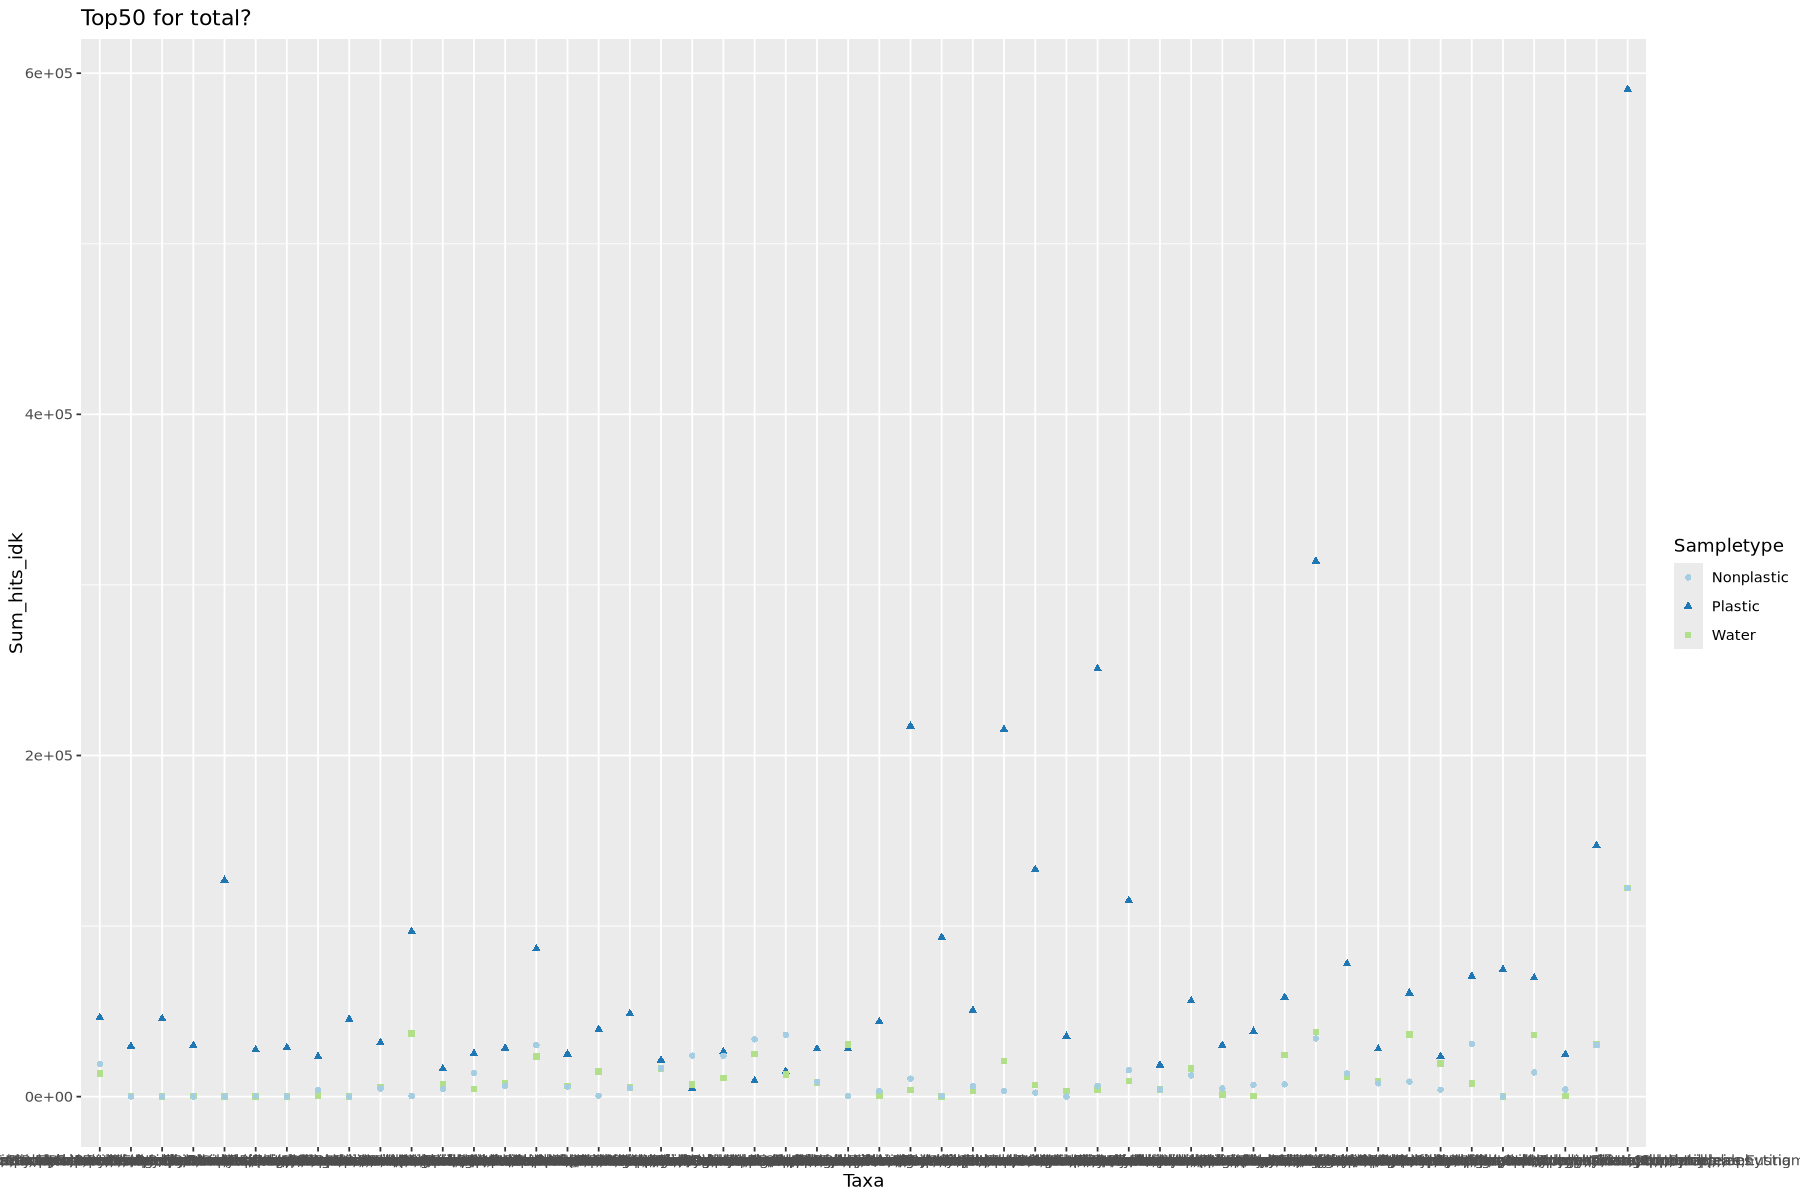

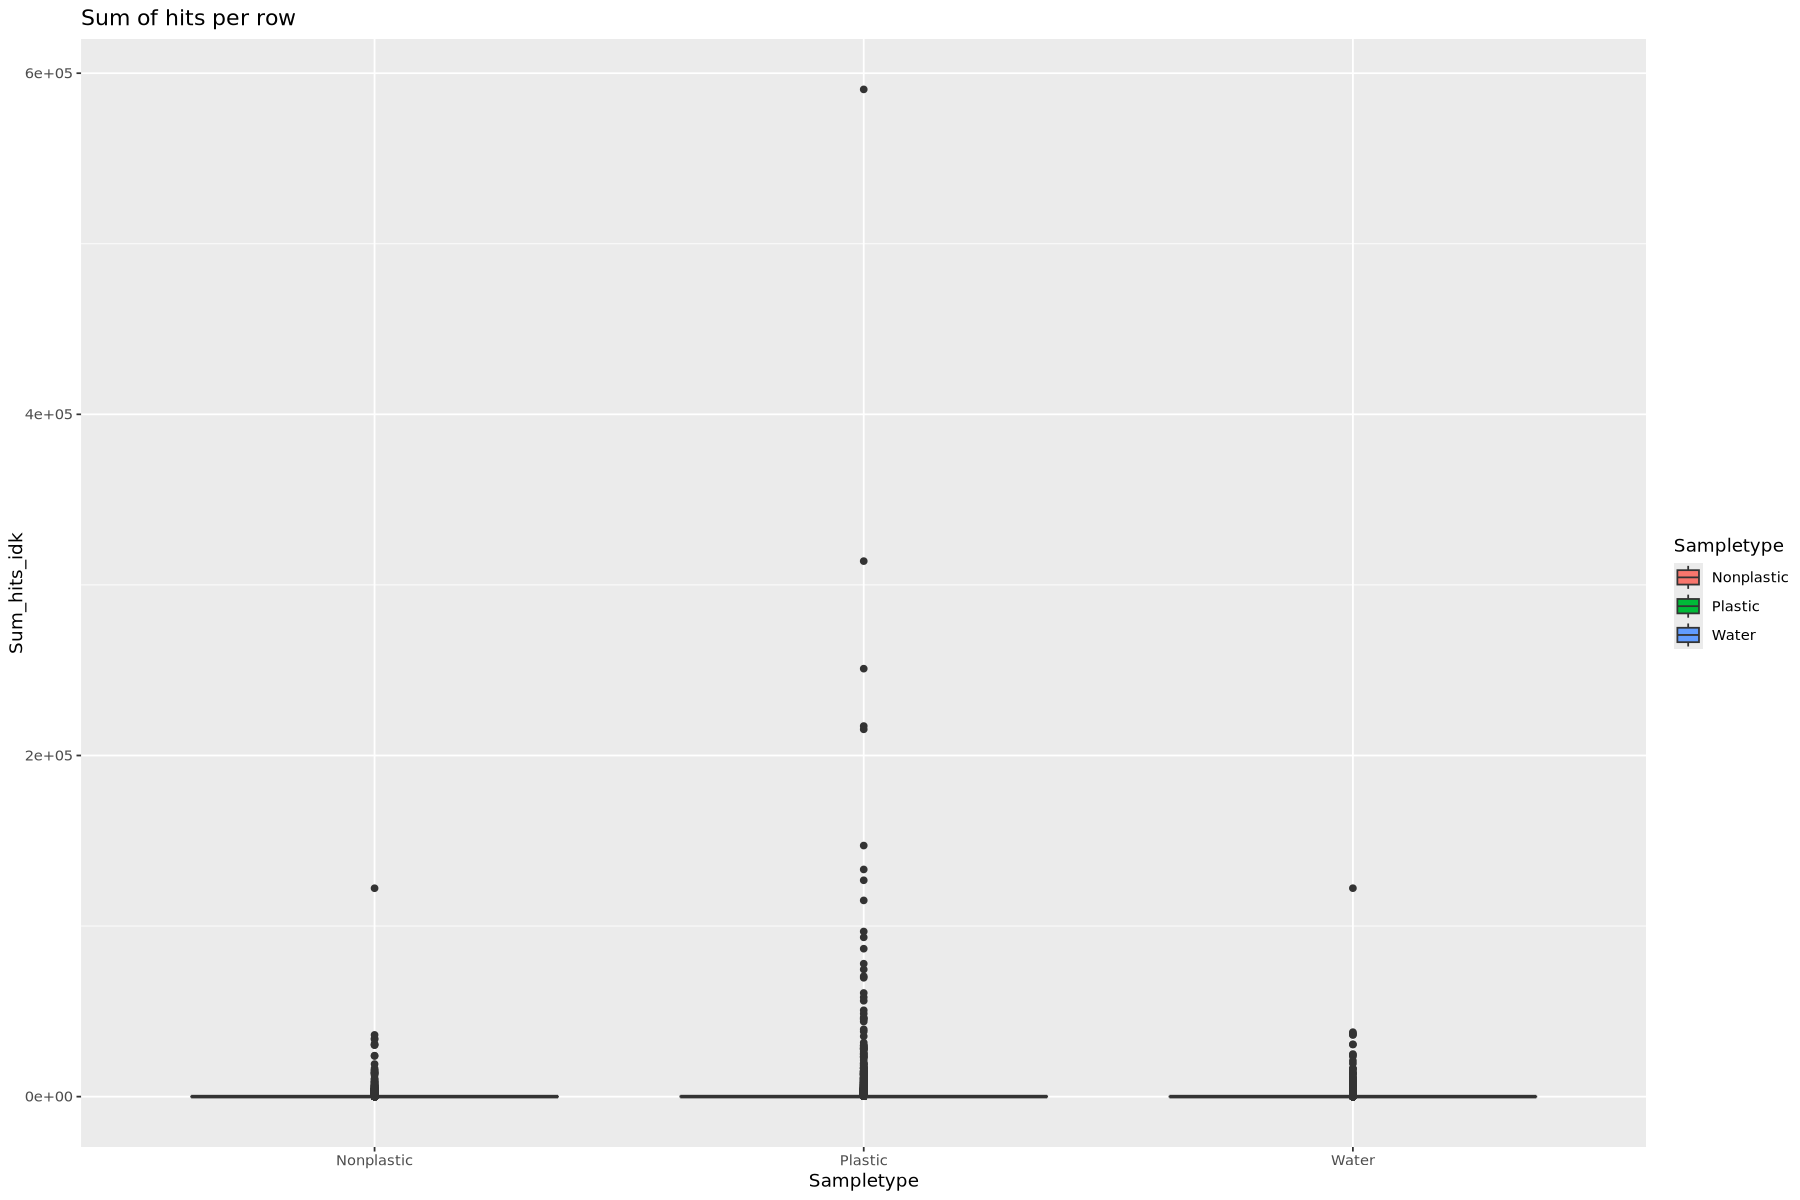

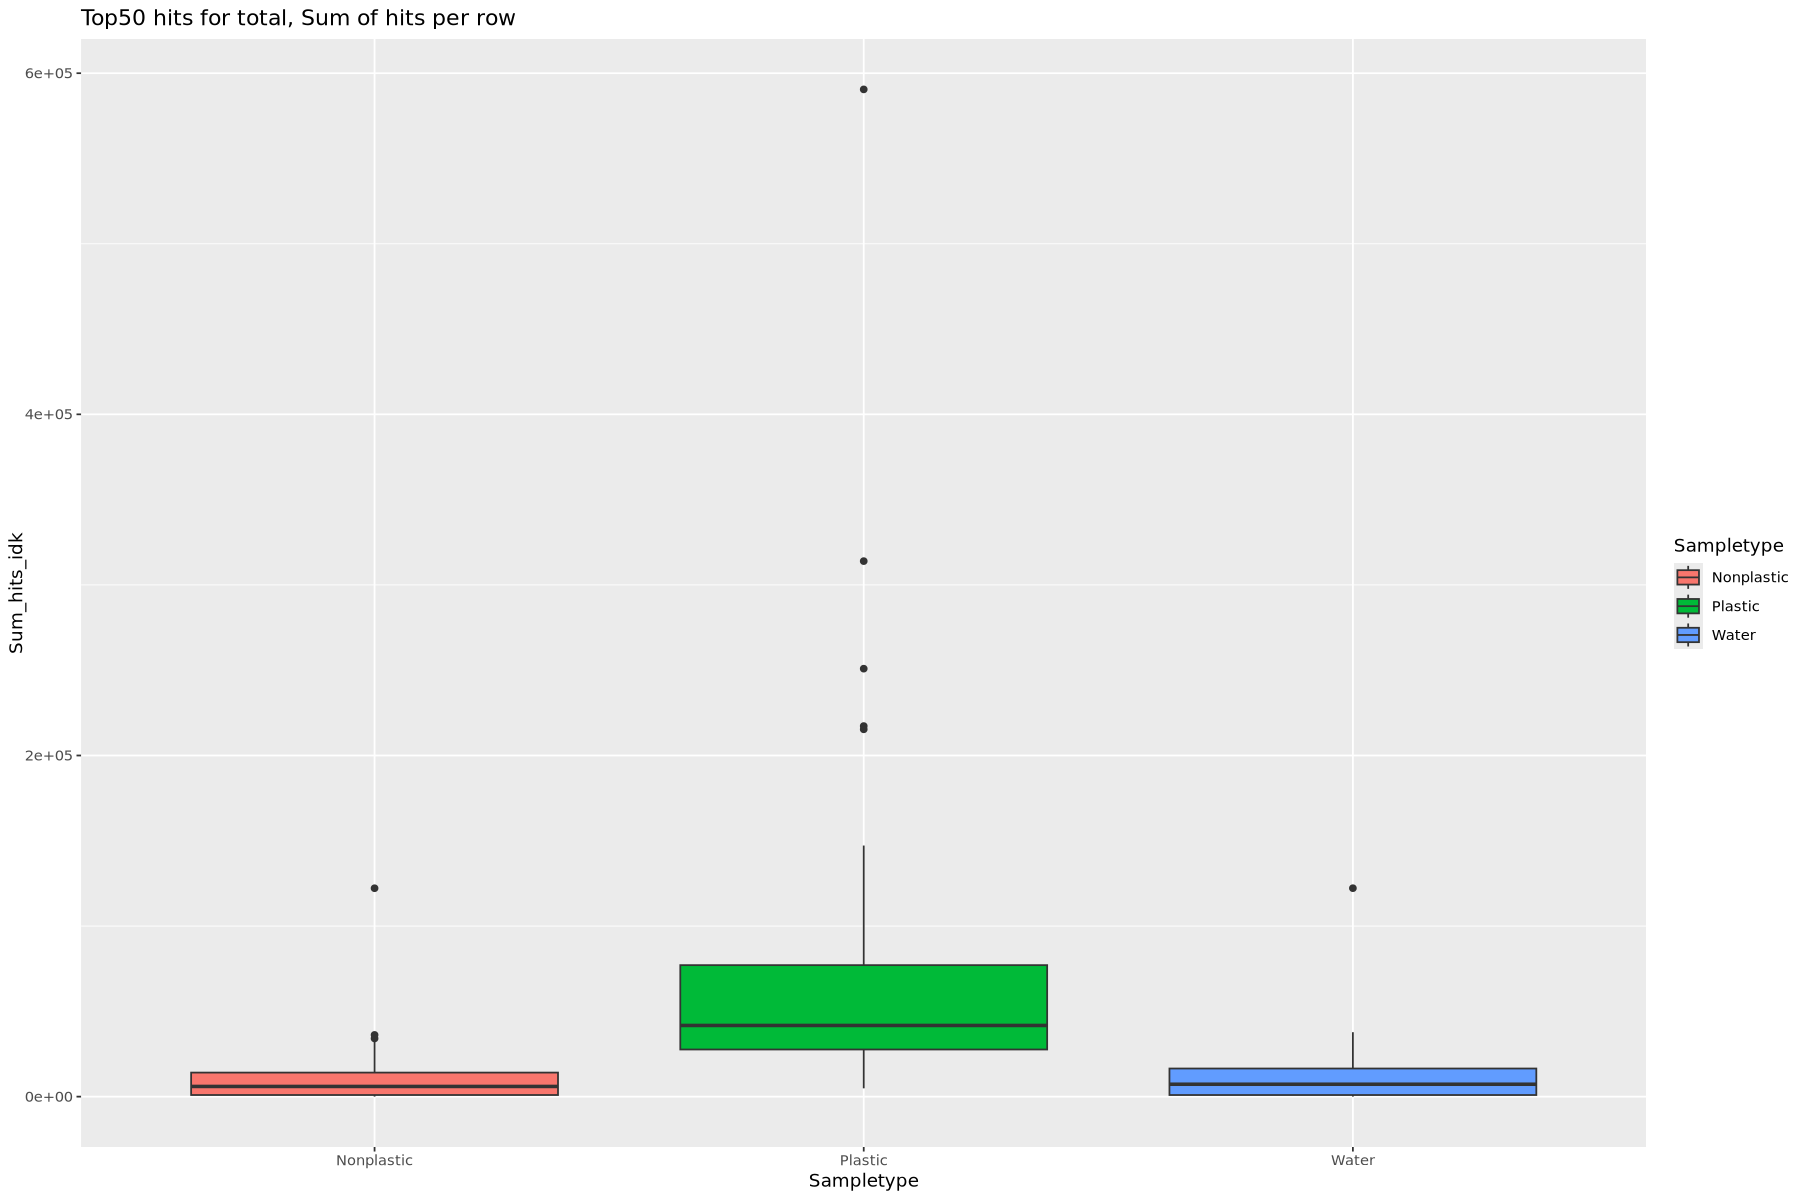

In [25]:
samples_plastic <- sample_metadata %>%
    filter(Sampletype == "Plastic")
samples_water <- sample_metadata %>%
    filter(Sampletype == "Water")
samples_nonplastic <- sample_metadata %>%
    filter(Sampletype == "Non-plastic")

sampletype_sums <- metaxa_dc %>%
    #dplyr::select(DRR528401, DRR528402, Kingdom:Genus) %>%
    #mutate(Sum = dplyr::select(., !(Kingdom:Genus)) %>% rowSums())
    mutate(Plastic = dplyr::select(., contains(samples_plastic$run_accession)) %>% rowSums(),
           Water = dplyr::select(., contains(samples_water$run_accession)) %>% rowSums(),
           Nonplastic = dplyr::select(., contains(samples_nonplastic$run_accession)) %>% rowSums(),
           Total = dplyr::select(., !(Taxa:Genus),) %>% rowSums(na.rm = TRUE)) %>%
    dplyr::select((Taxa:Total))

# Filter for the top 50 for each sampletype
sampletype_sums_top50 <- sampletype_sums %>%
    pivot_longer(c(Plastic, Water, Nonplastic, Total), names_to = "Sampletype", values_to = "Sum_hits_idk") %>%
    group_by(Sampletype) %>%
    # Get top 50 for each substrate type
    slice_max(Sum_hits_idk, n = 50) %>%
    # Get 94 different rows from this -> not all are the same for the different substrate types!
    pivot_wider(names_from = Sampletype, values_from = Sum_hits_idk) %>%
    # Replace all NA:s with zeros
    mutate_all(~replace(., is.na(.), 0))

#head(sampletype_sums, n = 20)

# All this is useless, since there are more plastic samples, would need sampling depth or something?
sampletype_sums_relative <- sampletype_sums %>%
    rename(Plastic_sum = Plastic,
           Water_sum = Water,
           Nonplastic_sum = Nonplastic) %>%
    # Calculate relative abundance: Type / Total
    #mutate(across(ends_with('-Mut'), ~ . / (. + get(str_replace(cur_column(), "-Mut$", "-WT"))), .names = "{.col}_relative")) %>%
    mutate(across(ends_with("sum"), ~ . / get("Total"), .names = "{.col}_relative")) %>%
    # Remove part of the name, so the new columns are named "SAMPLENAME_[12]_relative"
    rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_sum_relative")) %>%
    # Select away count-columns
    dplyr::select(-ends_with("sum")) 
    # Remove the "_relative" from the same columns as before, now just named SAMPLENAME_[12]

#rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_relative")) %>%

#sampletype_sums <- sampletype_sums_relative# sampletype_sums_top50

sampletype_sums %>%
    pivot_longer(c(Plastic, Water, Nonplastic, Total), names_to = "Sampletype", values_to = "Sum_hits_idk") %>%
#    slice_max(Total_sum, n = 50) %>%
    filter(Sampletype != "Total") %>%
    ggplot(aes(Taxa, Sum_hits_idk, col = Sampletype, shape = Sampletype))+
        scale_color_brewer(palette = "Paired") + 
        geom_point()+
        labs(title = "All rows, all hits?")

sampletype_sums %>%
    slice_max(Total, n = 50) %>%
    pivot_longer(c(Plastic, Water, Nonplastic, Total), names_to = "Sampletype", values_to = "Sum_hits_idk") %>%
    filter(Sampletype != "Total") %>%
    ggplot(aes(Taxa, Sum_hits_idk, col = Sampletype, shape = Sampletype))+
        scale_color_brewer(palette = "Paired") + 
        geom_point()+
        labs(title = "Top50 for total?")

sampletype_sums %>%
    #slice_max(Total, n = 50) %>%
    dplyr::select(!Total) %>%
    pivot_longer(c(Plastic, Water, Nonplastic), names_to = "Sampletype", values_to = "Sum_hits_idk") %>%
    ggplot(aes(Sampletype, Sum_hits_idk, fill = Sampletype))+
        scale_color_brewer(palette = "Paired") + 
        geom_boxplot()+
        labs(title = "Sum of hits per row")

sampletype_sums %>%
    slice_max(Total, n = 50) %>%
    dplyr::select(!Total) %>%
    pivot_longer(c(Plastic, Water, Nonplastic), names_to = "Sampletype", values_to = "Sum_hits_idk") %>%
    ggplot(aes(Sampletype, Sum_hits_idk, fill = Sampletype))+
        scale_color_brewer(palette = "Paired") + 
        geom_boxplot()+
        labs(title = "Top50 hits for total, Sum of hits per row")

In [26]:
#df_counts[which(str_detect(df_counts$Description, 'A1085V')), ]
#df_counts

#head(microeco_otutable)
#microeco_otutable
#head(microeco_sampleinfo)
#head(microeco_taxtable)
#microeco_taxtable
#sum(names(microeco_otutable) %in% rownames(microeco_sampleinfo))
#dim(microeco_sampleinfo)

#head(df_relative)
#head(df_counts)
#head(df_sample_metadata)

#data(selex)
#selex

# Barplot for hits per gene

Description,Fullname,Hits,Sample,run_accession,Type,Mutations,Name,Accession,Model Type,⋯,CARD Short Name,source,AMR Gene Family,Drug Class,Resistance Mechanism,study_accession,Sampletype,Substrate,Latitude,Longitude
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
A109T:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,DRR528401_1-Mut,0,DRR528401_1,DRR528401,Mut,A109T,Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,3003392,protein variant model,⋯,Mtub_katG_INH,WHO-R,isoniazid resistant katG,isoniazid-like antibiotic,antibiotic target alteration,PRJDB17400,Plastic,Plastic,35.834,139.607


Warning message:
“Removed 560 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Saving 7 x 7 in image
Warning message:
“Removed 560 rows containing missing values or values outside the scale range
(`geom_bar()`).”


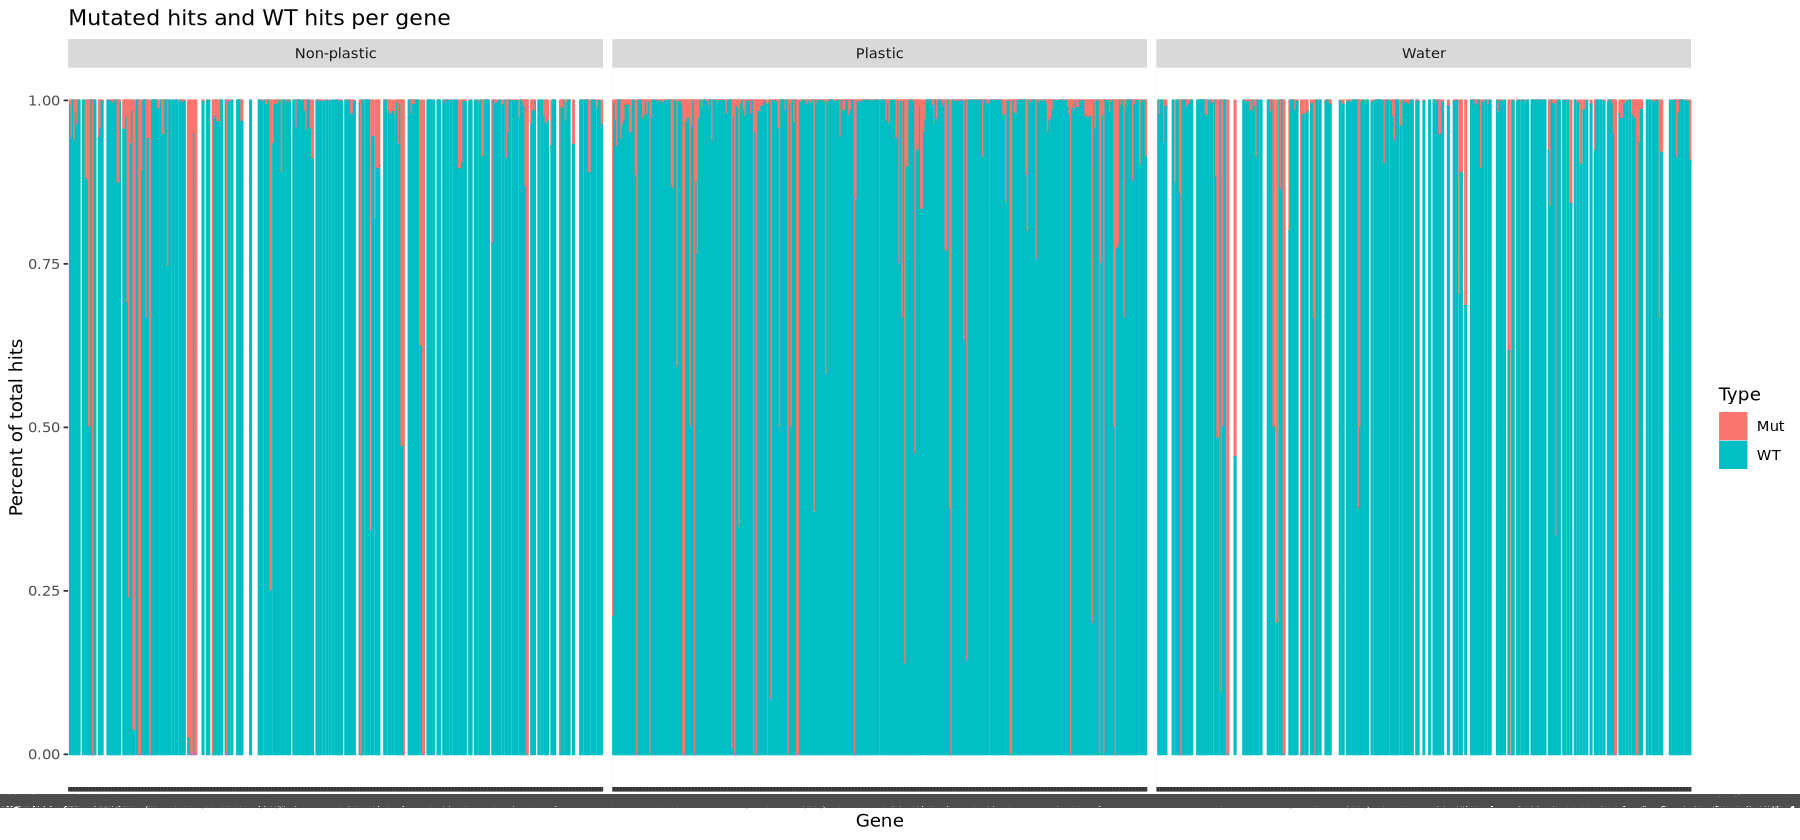

In [32]:
## Calculate relative abundance: Mut / (Mut + WT)
#mutate(across(ends_with('-Mut'), ~ . / (. + get(str_replace(cur_column(), "-Mut$", "-WT"))), .names = "{.col}_relative")) %>%
## Remove part of the name, so the new columns are named "SAMPLENAME_[12]_relative"
#rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_val-Mut")) %>%

df_long_count <- df_counts %>%
    mutate_all(~replace(., is.na(.), 0)) %>%
    rename_at(vars(contains('_val')), ~ str_remove(., "\\_val")) %>%
    pivot_longer(!Description, names_to = "Fullname", values_to = "Hits") %>%
    mutate(Sample = str_remove(Fullname, "\\-(Mut|WT)"),
           run_accession = str_remove(Fullname, "\\_[12]-(Mut|WT)"),
           Type = str_remove(Fullname, ".*-")) %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession") %>%
    left_join(sample_metadata, by = join_by(run_accession, Sample)) 
head(df_long_count, n = 1)

options(repr.plot.width=15, repr.plot.height=7)
df_long_count %>%
    filter(Mutations != "Wildtype") %>%
    group_by(Description, Type, Sampletype) %>%
    summarise(Total_hits = sum(Hits), .groups = "keep") %>%
    #filter(Total_hits > 0) %>%
    #filter(Type == "Mut") %>%
    ggplot(aes(Description, Total_hits, col = Type, fill = Type))+
        #geom_point()+
        geom_bar(position="fill", stat="identity") + 
        facet_wrap(~ Sampletype)+
        labs(title = "Mutated hits and WT hits per gene")+
        ylab("Percent of total hits")+
        xlab("Gene")
        #ylim(c(0, 10))
if (save_plots) ggsave("figs/percent_relative_genes_bars.png")

#head(df_counts)
#head(df_long_relative)